In [1]:
# set your working directory
import os
os.getcwd()
os.chdir('C:/Users/Mark/Documents/GitHub/eos_biomarkers/')

In [2]:
# import packages

# general math, stats, dataframe handling
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import random

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# imputation, random forests things
from itertools import compress
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score,confusion_matrix
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings("ignore")

# data:
df = pd.read_csv("data/allbatchesclin.csv") # normalized ms data for each protein for each sample w/ log2 abundance
new_df = pd.read_csv('data/leena_proteins_mean2023_nu037fix.csv', index_col = 0) # reshaped dataframe w/ rows for each sample & cols for each protein + some clinical variables
# ^ this differs from the one generated in the code; correct sex info was manually added for nu037.
psmetadata = pd.read_csv('data/ps_metadata_cut.csv') # metadata for each sample
# this differs from ps_metadata.csv in that 1. it lacks chart notes and 2. BP484 & NU125 have been recoded to 1 for prom
mesoscale = pd.read_excel('data/cord_mesoscaledata_12_9_22.xlsx', engine='openpyxl')


In [3]:
# manual data cleaning- to fix inaccurately coded info

# df = df.drop(df[(df['sample_id']=='NU236') & (df['sample_type']!='Control')].index, axis = 0)
# df.loc[df[df['sample_id'] == 'NU037']['sample_type'].index, 'sample_type'] = 'Control'
# df.loc[df[df['sample_id'] == 'NU236']['sample_type'].index, 'sample_type'] = 'Control'
# df = df[df['sample_id']!='PC']

In [4]:
#code to reshape the data

# new_df = pd.DataFrame()
# for protein in df['Gene names'].unique():
#     for sampleid in df['sample_id'].unique():
# #         print(protein, sampleid)
#         if df[(df['Gene names']==protein) & (df['sample_id']==sampleid)]['value_log2nb'].isnull().sum() == 0:
#             new_df.at[sampleid, protein] = df[(df['Gene names']==protein) & (df['sample_id']==sampleid)]['value_log2nb'].mean()
#         elif df[(df['Gene names']==protein) & (df['sample_id']==sampleid)]['value_log2nb'].isnull().sum() == 1:
#             new_df.at[sampleid, protein] = df[(df['Gene names']==protein) & (df['sample_id']==sampleid) & (df['value_log2nb'].notnull())]['value_log2nb'].iloc[0]
#         elif df[(df['Gene names']==protein) & (df['sample_id']==sampleid)]['value_log2nb'].isnull().sum() == 2:
#             new_df.at[sampleid, protein] = None
#     print(new_df)
# for sid in new_df.index:
#     for col in ['ga_cat', 'epoch', 'sample_type', 'GA_wks','batch']:
#         print(df[df['sample_id']==sid][col].unique()[0])
# #     for col in ['sample_type']:
#         new_df.loc[sid, col] = df[df['sample_id']==sid][col].unique()[0]

# new_df.to_csv('data/leena_proteins_mean2023.csv')

In [5]:
#incorporating sex into the analysis
merge_df = df.loc[:,['sex','sample_id']]
merge_df = merge_df.drop_duplicates()
new_df['sample_id'] = new_df.index
new_df = pd.merge(new_df, merge_df, how = 'left', on = 'sample_id')


In [6]:
print(new_df[new_df['sample_id'] == 'NU037'])
# NU037 has data for sex, gestational age, etc, in ps_metadata.csv but not in allbatchesclin.csv or in the file that becomes new_df
# I manually copied the data from ps_metadata.csv into the file that becomes new_df, but it's too laborious to fix allbatchesclin
# so it needs manual removal since the discrepancy duplicates it.
new_df = new_df.drop(new_df[(new_df['sample_id'] == 'NU037') & (new_df['sex'].isna())].index, axis=0)

          ALB  HP;HPR   SERPINA1        A2M      IGHG1      IGHG2  IGHG3  \
95  31.732363     NaN  28.198313  27.536863  27.768313  22.924263    NaN   
96  31.732363     NaN  28.198313  27.536863  27.768313  22.924263    NaN   

        APOA1        FGA  FGB  ...  PSME2  CORO1C  CLIC4;CLIC2;CLIC5;CLIC6  \
95  31.524213  25.201763  NaN  ...    NaN     NaN                      NaN   
96  31.524213  25.201763  NaN  ...    NaN     NaN                      NaN   

    ga_cat  epoch  sample_type  GA_wks  batch  sample_id   sex  
95    >=37      4      Control   37.29      2      NU037   NaN  
96    >=37      4      Control   37.29      2      NU037  Male  

[2 rows x 444 columns]


In [7]:
#removing all the controls and presumed sepsis patients
new_df = new_df[new_df['sample_type'] != 'PS_nonclassicEOS']
new_df = new_df[new_df['sample_type'] != 'nonclassicEOS']
new_df = new_df[new_df['sample_type'] != 'Control + degradation assessment sample']
new_df = new_df[new_df['sample_type'] != 'PS_nonclassic EOS']
new_df = new_df[new_df['sample_type'] != 'pooled_control']
new_df = new_df[new_df['sample_type'] != 'PS']

In [8]:
#removing proteins that have over 80% missingness
tmp = new_df.isnull().sum()/new_df.shape[0]
new_df =  new_df.drop(tmp[tmp>0.80].index, axis = 1)

In [9]:
# imputing values for heatmap visualizations (which do not play nice with NAs)
# first: for proteins with less than 30% missingness, use an iterative imputer by sample type
# then: for proteins with greater missingness, just sample from the bottom 10% of values
# the rationale for this approach is that since most missing proteins arose from batch effects,
#   and the batches are 25% each, so proteins with >25-30% missingness are most likely truly non-abundant
#   rather than just not detected in a given batch.

new_df_imp = new_df.copy() #copy it
imputeddf = pd.DataFrame() # this is to save just the imputed things
imp = IterativeImputer(max_iter=10, random_state=0) #define iterative imputer funxion

#for st in ['EOS','Control','PS']:
for st in ['EOS','Control']: #do the following for each sample type:
    tmp = new_df[new_df['sample_type'] == st] #store in tmp only the rows in new_df that have the current sample type
    vals =  tmp.iloc[:, :-7] # grab all cols except the last seven! which are metadata.
    missing = vals.isnull().sum()/vals.shape[0] #for each column, what % are missing?
    keep = missing[missing<0.3].index # names of columns (proteins) where they mostly aren't missing.
    vals_imp = imp.fit_transform(vals.loc[:,keep]) # for the proteins in keep, impute
    vals_imp = pd.DataFrame(vals_imp, index = vals.index, columns = keep) #make it a dataframe
    new_df_imp.loc[vals_imp.index, vals_imp.columns] = vals_imp
    imputeddf = pd.concat([imputeddf, vals_imp]) # save just the imputed things
imputed_labels = new_df.loc[new_df_imp.index, 'sample_type']
imputed_sampleid = new_df.loc[new_df_imp.index, 'sample_id']

#imputing missing values by sampling from bottom 10% of values per protein for proteins not previously dealt with
for prot in new_df.columns[:-7]:
    if not new_df[prot].isnull().any(): 
        continue 
    quantile = new_df[prot].quantile(0.05)
    min_val = new_df[new_df[prot]<quantile][prot].min()
    max_val = new_df[new_df[prot]<quantile][prot].max()
    for idx in new_df_imp[new_df_imp[prot].isnull()][prot].index:
        sample = random.uniform(min_val, max_val) #bottom 10% 
        #sample = 0
        new_df_imp.at[idx,prot] = sample
        imputeddf.at[idx,prot] = sample

In [10]:
# make a df with NAs imputed with zeros, to show how much/what is getting imputed
new_df_zimp = new_df.copy() #copy it 

for prot in new_df.columns[0:-7]:
    for idx in new_df[new_df[prot].isnull()][prot].index:
        new_df_zimp.at[idx,prot] = 0

In [11]:
# remove problematic bits. columns with unexpected strings + NAs
tmp = new_df_imp.isna().sum()
tmp[tmp != 0]
#imp_clean =  new_df_imp.drop(tmp[tmp>0].index, axis = 1).drop(columns=['sample_id', 'Unnamed: 0'])
imp_clean =  new_df_imp.drop(tmp[tmp>0].index, axis = 1).drop(columns=['sample_id'])
# this basically just removes epoch

In [12]:
##########################
### FIGURES START HERE ###
##########################

In [13]:
### Figure 1

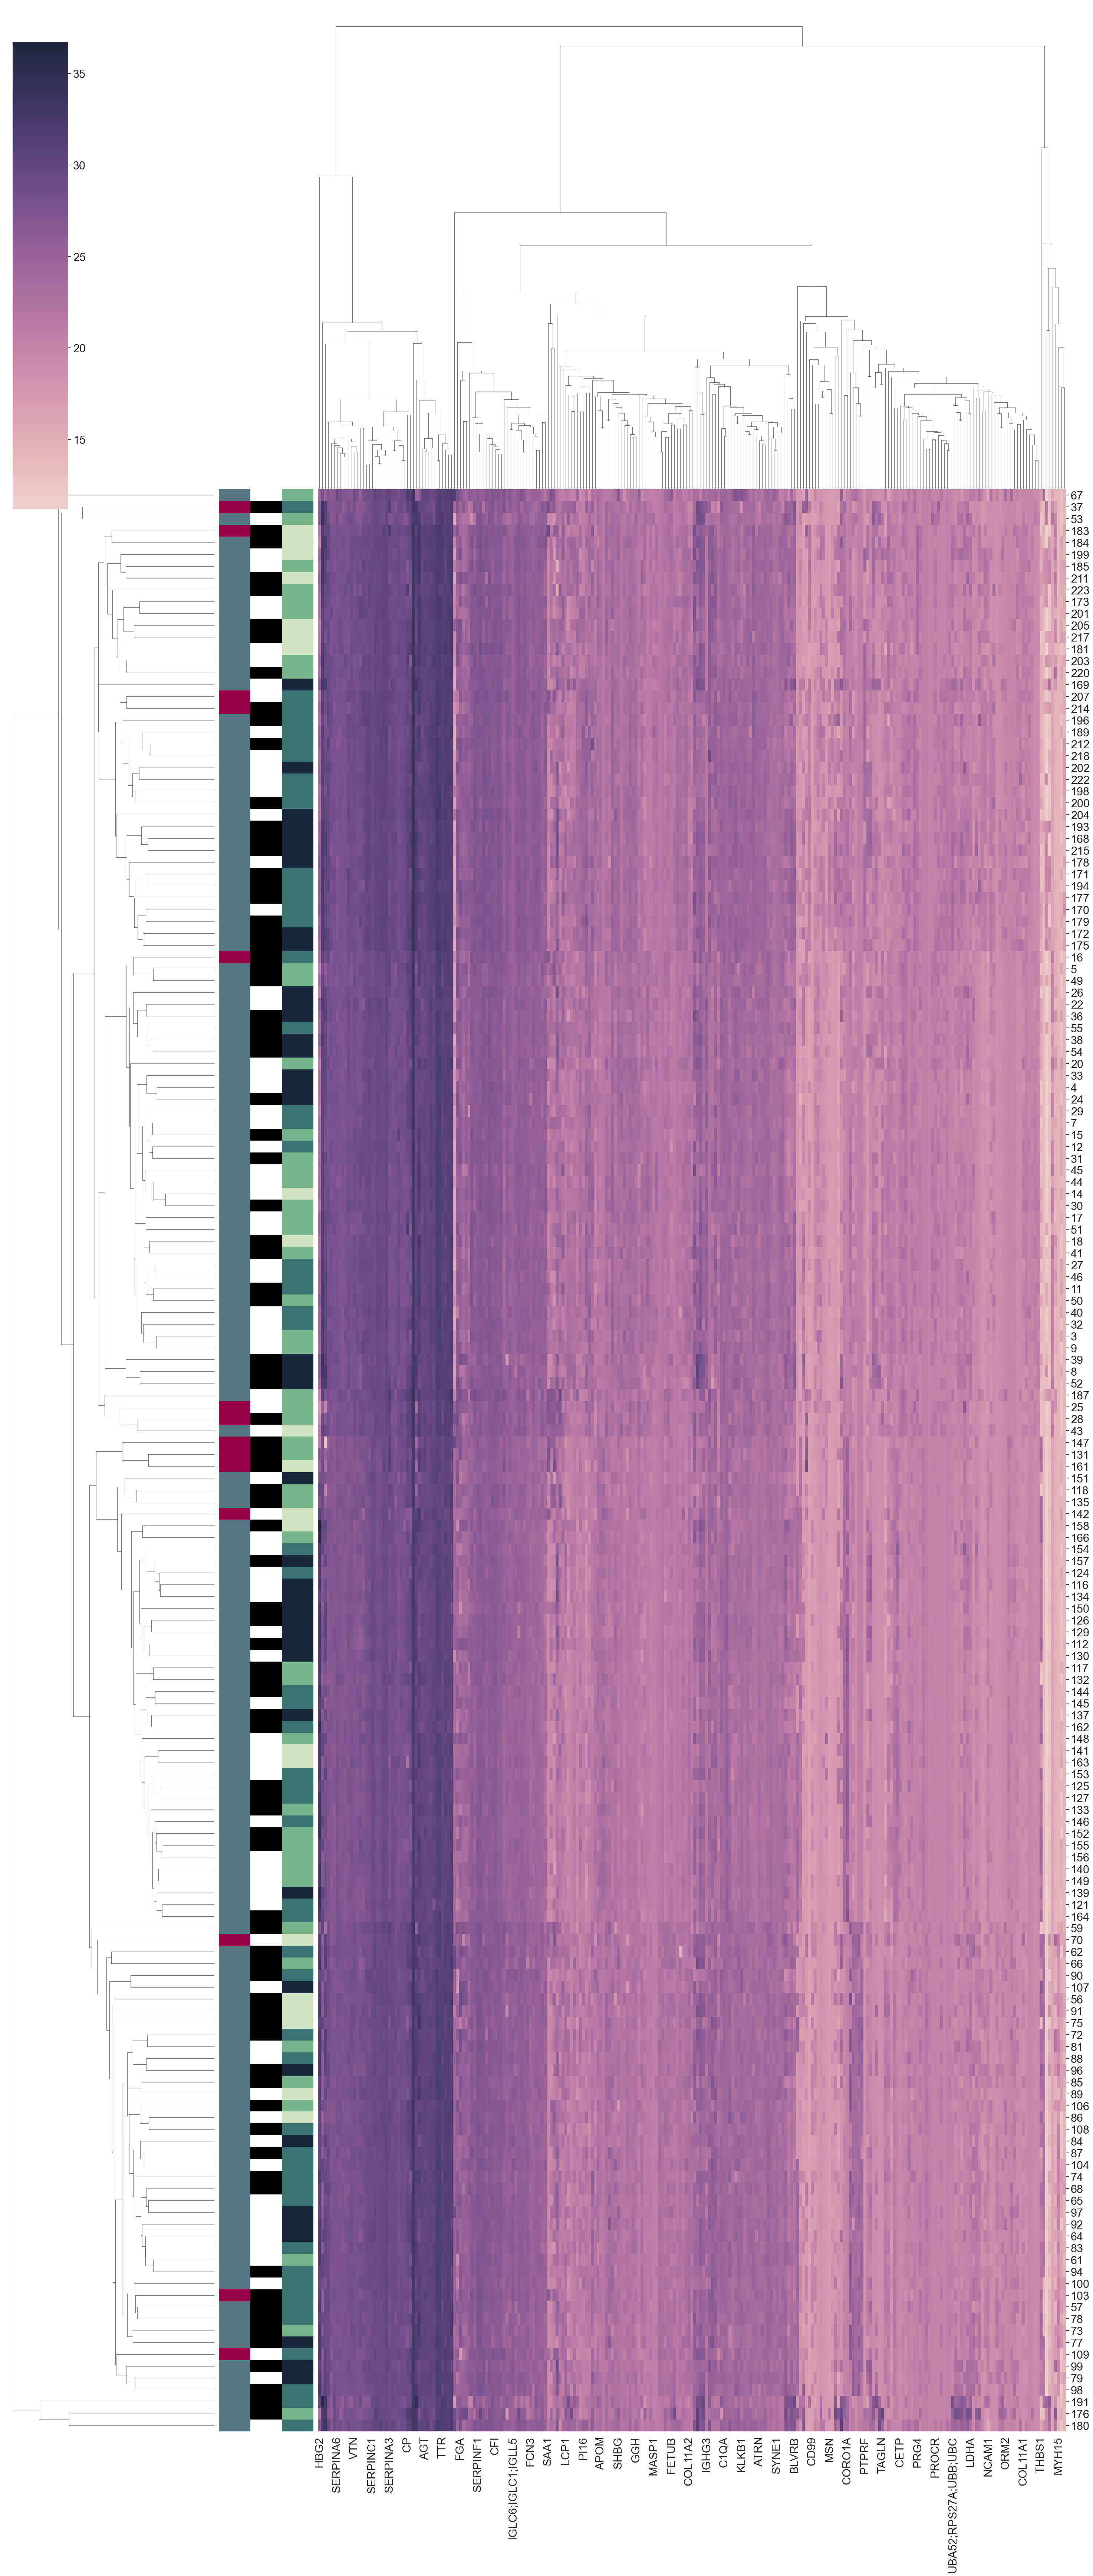

In [14]:
#creating a heatmap and clustering by proteins and samples to see if there are trends associated with sample type, sex or GA weeks
#lut = {'EOS': sns.color_palette("Set3")[3], 'Control': sns.color_palette("Set3")[4], 'PS': 'g'}
#lut = {'EOS': sns.color_palette("husl", 8)[0], 'Control': sns.color_palette("husl", 8)[5], 'PS': 'g'}
lut = {'EOS': '#940043', 'Control': '#577483', 'PS': 'goldenrod'}
fourcol= sns.cubehelix_palette(start=3, rot=-.5, as_cmap=False, n_colors=4) #start =0.5 for pleasant blue, 
lut_ga = {'<28': fourcol[0], '28- <32': fourcol[1], '32-36': fourcol[2], '>=37': fourcol[3], None:'lightpink'}

lut_sex = {'Female': 'white', 'Male': 'black', None:'lightpink'}

row_colors_sample = imp_clean['sample_type'].map(lut)
row_colors_ga = imp_clean['ga_cat'].map(lut_ga)
row_colors_sex = imp_clean['sex'].map(lut_sex)
sns.set(font_scale=2)
testt = sns.cubehelix_palette(start =-0.3, rot=0.5, as_cmap=True, reverse=False)#0.3 for nice purple

sns.clustermap(imp_clean.iloc[:,0:-5], cmap = testt, figsize = [30,70],yticklabels = True,col_cluster = True, row_colors=[row_colors_sample,pd.Series(row_colors_sex).fillna('dimgray'),pd.Series(row_colors_ga).fillna('dimgray')])
plt.savefig('graphs/fig1_heatmap_imputed.eps', format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [13]:
#write data to a csv for supplementary data file:
f1b_rawdata = new_df_imp.drop(tmp[tmp>0].index, axis = 1)
# Save the dataset to a .csv file
f1b_rawdata.to_csv('extendeddata/f1b_data.csv', index=False)


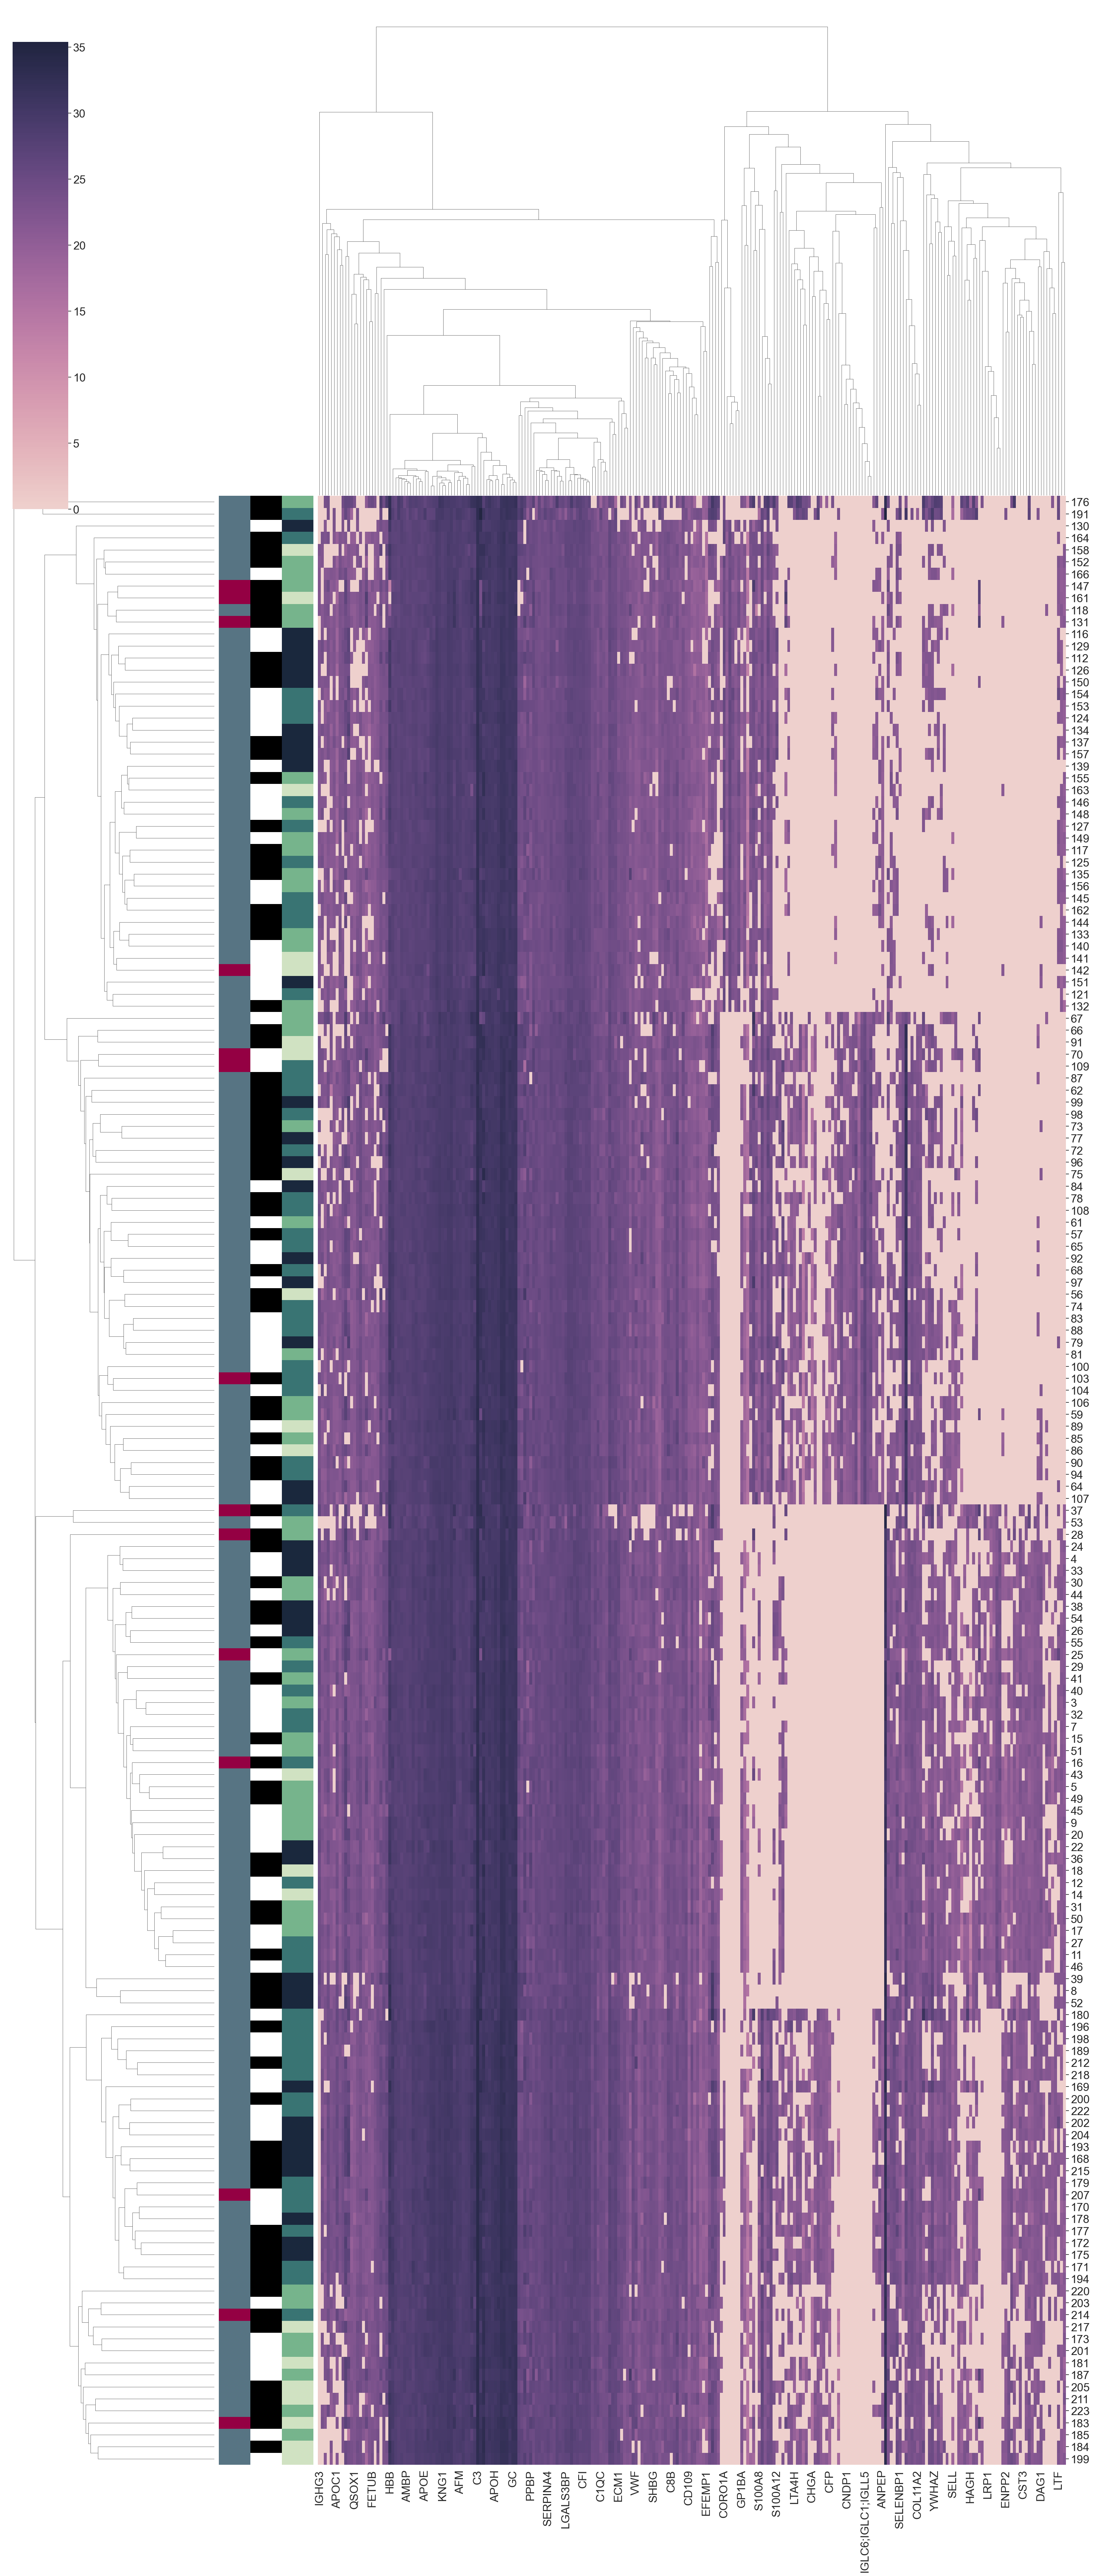

In [14]:
# supplemental figure 1: heatmap with NAs imputed with 0, to show what/how much imputation affects
# remove problematic bits. columns with unexpected strings + NAs
tmpz = new_df_zimp.isna().sum()
#imp_clean =  new_df_imp.drop(tmp[tmp>0].index, axis = 1).drop(columns=['sample_id', 'Unnamed: 0'])
zimp_clean =  new_df_zimp.drop(tmp[tmp>0].index, axis = 1).drop(columns=['sample_id'])

#creating a heatmap and clustering by proteins and samples to see if there are trends associated with sample type, sex or GA weeks
#lut = {'EOS': sns.color_palette("Set3")[3], 'Control': sns.color_palette("Set3")[4], 'PS': 'g'}
#lut = {'EOS': sns.color_palette("husl", 8)[0], 'Control': sns.color_palette("husl", 8)[5], 'PS': 'g'}
lut = {'EOS': '#940043', 'Control': '#577483', 'PS': 'g'}
fourcol= sns.cubehelix_palette(start=3, rot=-.5, as_cmap=False, n_colors=4) #start =0.5 for pleasant blue, 
lut_ga = {'<28': fourcol[0], '28- <32': fourcol[1], '32-36': fourcol[2], '>=37': fourcol[3], None:'lightpink'}

lut_sex = {'Female': 'white', 'Male': 'black', None:'lightpink'}

row_colors_sample = zimp_clean['sample_type'].map(lut)
row_colors_ga = zimp_clean['ga_cat'].map(lut_ga)
row_colors_sex = zimp_clean['sex'].map(lut_sex)
sns.set(font_scale=2)
testt = sns.cubehelix_palette(start =-0.3, rot=0.5, as_cmap=True, reverse=False)#0.3 for nice purple

sns.clustermap(zimp_clean.iloc[:,0:-5], cmap = testt, figsize = [30,70],yticklabels = True,col_cluster = True, row_colors=[row_colors_sample,pd.Series(row_colors_sex).fillna('dimgray'),pd.Series(row_colors_ga).fillna('dimgray')])
plt.savefig('graphs/suppfig1_heatmap_zeros.eps', format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [15]:
s1_data = new_df
s1_data.to_csv('extendeddata/s1_data.csv', index=False)


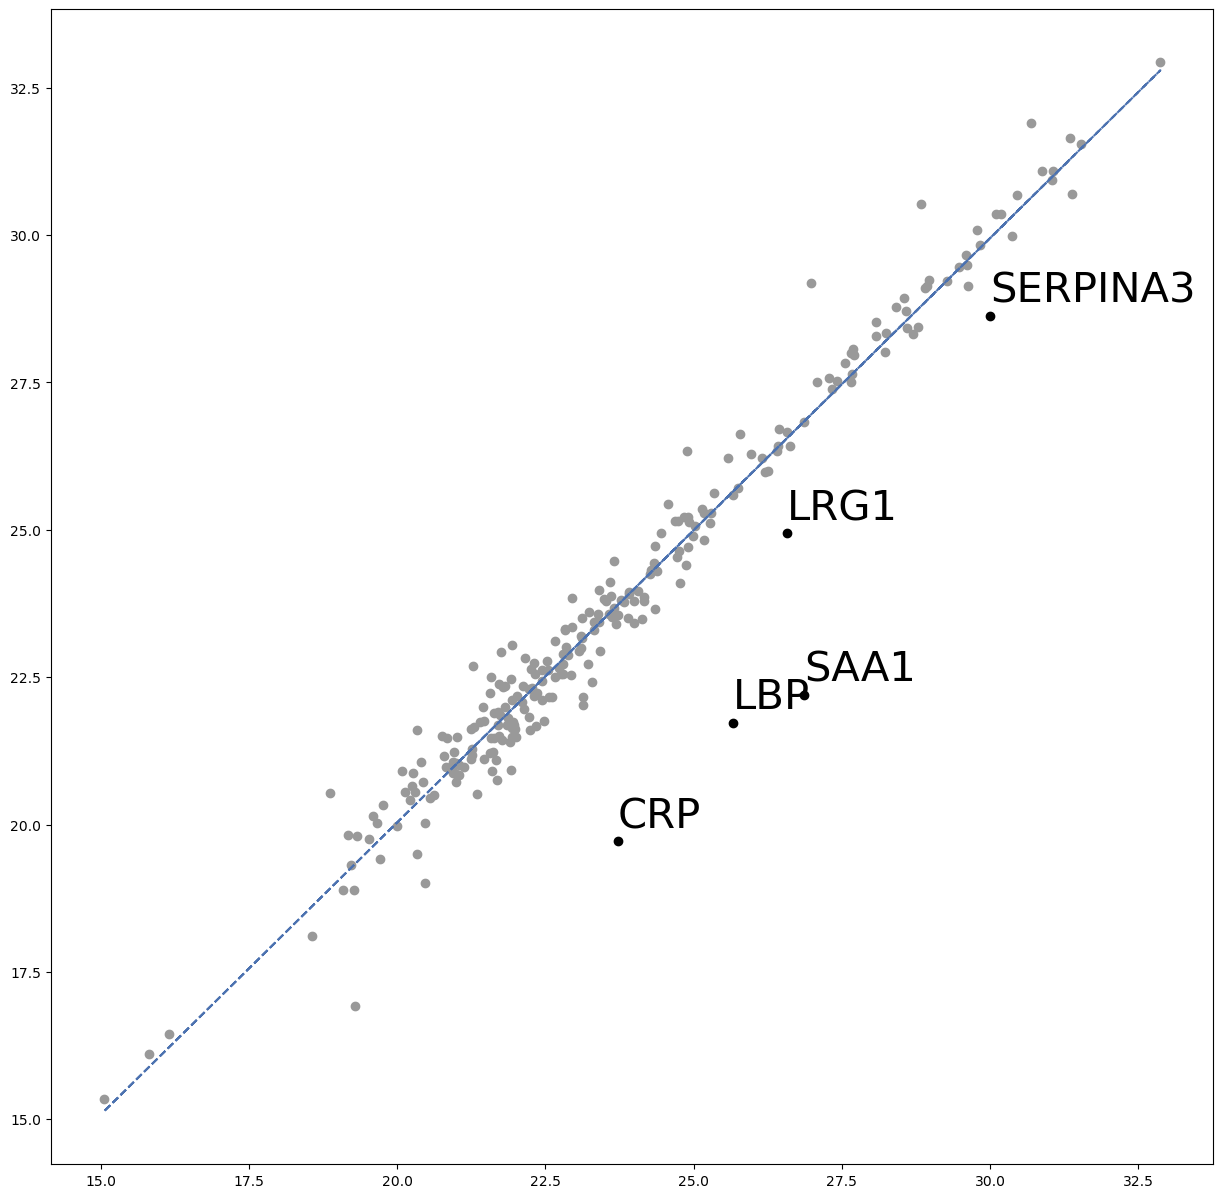

In [24]:
# identifying proteins that are significantly different between EOS and control using mann whitney 
# then correcting for multiple comparisons with bejamini hochberg fdr
# visualizing different proteins by plotting mean of EOS vs mean of Control for each protein
sns.reset_orig()
names = ['ctrl','ps', 'eos']
color = []

genes = []
pvals = []
eosmean = []
ctrlmean = []
psmean = []
foldchange = []

eosfrac = []
ctrlfrac = []
idx = []

#female = new_df[new_df['sex'] != 'Male']
#male = new_df[new_df['sex'] == 'Male']
#sensitivity = new_df[new_df['GA_wks'] < 37]
sex = new_df
for gene in new_df.columns:
    if gene != 'sample_id' and gene != 'ga_cat' and gene != 'epoch' and gene != 'sample_type' and gene != 'Unnamed: 0' and gene != 'GA_wks' and gene != 'batch' and gene != 'sex':
        ctrl = sex[sex['sample_type'] =='Control'][gene].dropna()
        ps = sex[sex['sample_type'] =='PS'][gene].dropna()
        eos = sex[sex['sample_type'] =='EOS'][gene].dropna()
        if eos.shape[0] == 0 or ctrl.shape[0] == 0:
            pass
        else:
            foldchange.append(np.log2(ctrl.mean()/eos.mean()))
            genes.append(gene)
            mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
            pvals.append(mann_whitneypval)
            #ttpval = stats.ttest_ind(eos, ctrl, equal_var=False).pvalue
           #ttpval = stats.ttest_ind(eos, ctrl).pvalue
            #pvals.append(ttpval)
            eosmean.append(eos.mean())
            ctrlmean.append(ctrl.mean())
            psmean.append(ps.mean())
            eoslen = eos.shape[0]/14
            contlen = ctrl.shape[0]/150
            eosfrac.append(eoslen)
            ctrlfrac.append(contlen)
            idx.append(abs(eoslen - contlen))
# print(multipletests(pvals, method = 'fdr_bh')[0])

siggenes = list(compress(genes, multipletests(pvals, method = 'fdr_bh')[0]))
z = np.polyfit(eosmean, ctrlmean, 1)
p = np.poly1d(z)

plt.figure(figsize = [15,15])
for g in range(len(genes)):
    gene = genes[g]
    if gene in siggenes:
        plt.scatter(eosmean[g], ctrlmean[g], color = 'black')
        plt.annotate(gene, (eosmean[g], ctrlmean[g]), textcoords = 'offset points', xytext=(0,10), fontsize = 30)
    else:
        plt.scatter(eosmean[g], ctrlmean[g], color = '#999999')
plt.plot(eosmean,p(eosmean),"b", linestyle='dashed')
plt.savefig('graphs/fig1_scatterplot.eps',format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

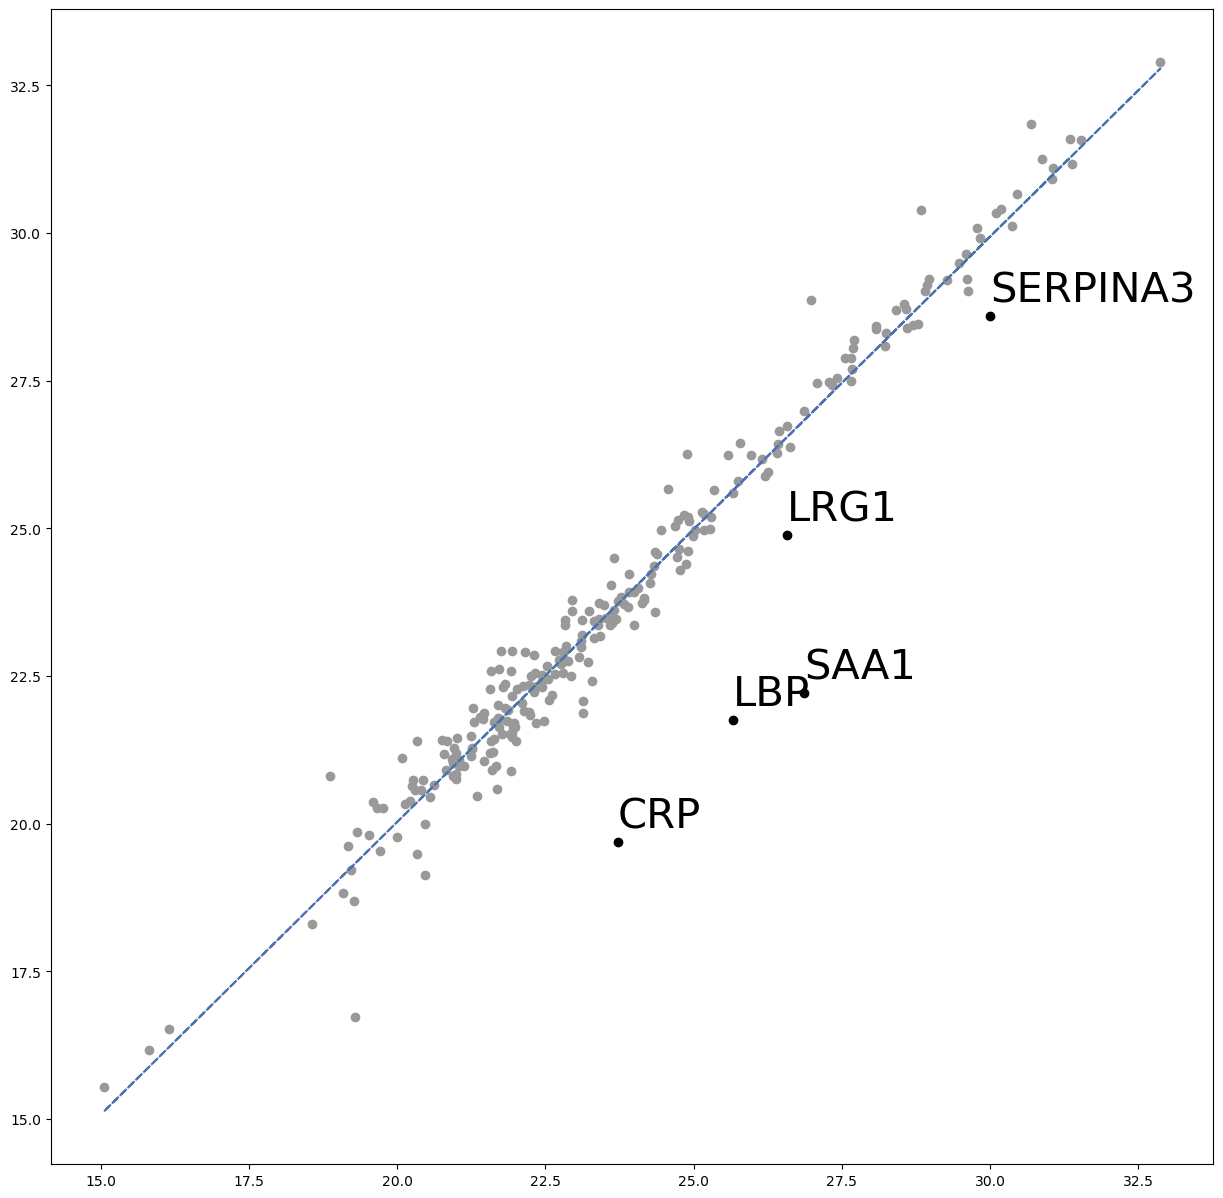

In [25]:
# identifying proteins that are significantly different between EOS and control using mann whitney 
# then correcting for multiple comparisons with bejamini hochberg fdr
# visualizing different proteins by plotting mean of EOS vs mean of Control for each protein
sns.reset_orig()
names = ['ctrl','ps', 'eos']
color = []

genes = []
pvals = []
eosmean = []
ctrlmean = []
psmean = []
foldchange = []

eosfrac = []
ctrlfrac = []
idx = []

#female = new_df[new_df['sex'] != 'Male']
#male = new_df[new_df['sex'] == 'Male']
sensitivity = new_df[new_df['GA_wks'] < 37]
sex = sensitivity
for gene in new_df.columns:
    if gene != 'sample_id' and gene != 'ga_cat' and gene != 'epoch' and gene != 'sample_type' and gene != 'Unnamed: 0' and gene != 'GA_wks' and gene != 'batch' and gene != 'sex':
        ctrl = sex[sex['sample_type'] =='Control'][gene].dropna()
        ps = sex[sex['sample_type'] =='PS'][gene].dropna()
        eos = sex[sex['sample_type'] =='EOS'][gene].dropna()
        if eos.shape[0] == 0 or ctrl.shape[0] == 0:
            pass
        else:
            foldchange.append(np.log2(ctrl.mean()/eos.mean()))
            genes.append(gene)
            mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
            pvals.append(mann_whitneypval)
            #ttpval = stats.ttest_ind(eos, ctrl, equal_var=False).pvalue
           #ttpval = stats.ttest_ind(eos, ctrl).pvalue
            #pvals.append(ttpval)
            eosmean.append(eos.mean())
            ctrlmean.append(ctrl.mean())
            psmean.append(ps.mean())
            eoslen = eos.shape[0]/14
            contlen = ctrl.shape[0]/150
            eosfrac.append(eoslen)
            ctrlfrac.append(contlen)
            idx.append(abs(eoslen - contlen))
# print(multipletests(pvals, method = 'fdr_bh')[0])

siggenes = list(compress(genes, multipletests(pvals, method = 'fdr_bh')[0]))
z = np.polyfit(eosmean, ctrlmean, 1)
p = np.poly1d(z)


plt.figure(figsize = [15,15])
for g in range(len(genes)):
    gene = genes[g]
    if gene in siggenes:
        plt.scatter(eosmean[g], ctrlmean[g], color = 'black')
        plt.annotate(gene, (eosmean[g], ctrlmean[g]), textcoords = 'offset points', xytext=(0,10), fontsize = 30)
    else:
        plt.scatter(eosmean[g], ctrlmean[g], color = '#999999')
plt.plot(eosmean,p(eosmean),"b", linestyle='dashed')
plt.savefig('graphs/sup2_scatterplot_sub37.eps',format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [28]:
# checking if there are any genes with high missingness that are potentially predictive of EOS


# read in the data again
uncut_df = pd.read_csv('data/leena_proteins_mean2023_nu037fix.csv', index_col = 0) # reshaped dataframe w/ rows for each sample & cols for each protein + some clinical variables

# identifying proteins that are significantly different between EOS and control using mann whitney 
# then correcting for multiple comparisons with bejamini hochberg
# visualizing different proteins by plotting mean of EOS vs mean of Control for each protein
sns.reset_orig()
names = ['ctrl','ps', 'eos']
color = []

genes = []
pvals = []
eosmean = []
ctrlmean = []
psmean = []
foldchange = []

eosfrac = []
ctrlfrac = []
totalfrac = []
idx = []


#female = new_df[new_df['sex'] != 'Male']
#male = new_df[new_df['sex'] == 'Male']
#sex = uncut_df[uncut_df['GA_wks'] < 37] # for sup fig 2 data
sex = uncut_df
for gene in uncut_df.columns:
    if gene != 'sample_id' and gene != 'ga_cat' and gene != 'epoch' and gene != 'sample_type' and gene != 'Unnamed: 0' and gene != 'GA_wks' and gene != 'batch' and gene != 'sex':
        ctrl = sex[sex['sample_type'] =='Control'][gene].dropna()
        ps = sex[sex['sample_type'] =='PS'][gene].dropna()
        eos = sex[sex['sample_type'] =='EOS'][gene].dropna()
        if eos.shape[0] == 0 or ctrl.shape[0] == 0:
            pass
        else:
            foldchange.append(np.log2(ctrl.mean()/eos.mean()))
            genes.append(gene)
            mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
            pvals.append(mann_whitneypval)
            #ttpval = stats.ttest_ind(eos, ctrl, equal_var=False).pvalue
           #ttpval = stats.ttest_ind(eos, ctrl).pvalue
            #pvals.append(ttpval)
            eosmean.append(eos.mean())
            ctrlmean.append(ctrl.mean())
            psmean.append(ps.mean())
            eoslen = eos.shape[0]/14
            contlen = ctrl.shape[0]/150
            totallen = (eos.shape[0] + ctrl.shape[0])/164
            eosfrac.append(eoslen)
            ctrlfrac.append(contlen)
            totalfrac.append(totallen)
            idx.append(abs(eoslen - contlen))
# print(multipletests(pvals, method = 'fdr_bh')[0])

siggenes = list(compress(genes, multipletests(pvals, method = 'fdr_bh')[0]))
z = np.polyfit(eosmean, ctrlmean, 1)
p = np.poly1d(z)

dff = pd.DataFrame({
    'genes': genes,
    'pvals': pvals,
    'ctrlmean': ctrlmean,
    'eosmean': eosmean,
    'foldchange': foldchange,
    'pvalcorr': multipletests(pvals, method = 'fdr_bh')[1],
    'eosfrac': eosfrac,
    'ctrlfrac': ctrlfrac,
    'totalfrac': totalfrac,
    'idx': idx
})

dff[(dff['idx'] > 0.2) & (dff['totalfrac'] < 0.2)]

,genes,pvals,ctrlmean,eosmean,foldchange,pvalcorr,eosfrac,ctrlfrac,totalfrac,idx
1,HP;HPR,0.122903,22.249182,22.988262,-0.047145,0.927712,0.428571,0.133333,0.158537,0.295238
117,SAA2,0.370629,22.619873,23.593062,-0.060772,0.948956,0.714286,0.020000,0.079268,0.694286
185,LCN2,0.284382,21.258611,22.263524,-0.066635,0.946755,0.357143,0.053333,0.079268,0.303810
213,LILRA3,0.402129,19.532981,19.715775,-0.013438,0.948956,0.428571,0.160000,0.182927,0.268571
259,MYH9,0.683842,22.018555,22.304771,-0.018633,1.000000,0.357143,0.153333,0.170732,0.203810
260,GP5,0.569474,20.585238,21.070979,-0.033647,0.998716,0.357143,0.140000,0.158537,0.217143


In [29]:
dff.to_csv('extendeddata/f1c_data.csv', index=False)
#dff.to_csv('extendeddata/s2a_data.csv', index=False) #for s2 data

In [30]:
# making demographics table

#removing all the controls and presumed sepsis patients
psmetadata = psmetadata[psmetadata['sample_type'] != 'PS_nonclassicEOS']
psmetadata = psmetadata[psmetadata['sample_type'] != 'nonclassicEOS']
psmetadata = psmetadata[psmetadata['sample_type'] != 'Control + degradation assessment sample']
psmetadata = psmetadata[psmetadata['sample_type'] != 'PS_nonclassic EOS']
psmetadata = psmetadata[psmetadata['sample_type'] != 'pooled_control']
#psmetadata = psmetadata[psmetadata['sample_type'] != 'PS']

# fix epoch data type
psmetadata['epoch'] = psmetadata['epoch'].astype(int)

# additionally, not all samples in the proteomics dataset were selected for mesoscale.
# to get accurate data for the presumed sepsis column and to assess whether the subset of controls that were msd'd reflects all controls:
# 1. make lists of which samples were mesoscaled in the different categories
ps_relevant = mesoscale.loc[mesoscale['CRP_avg_conc_pg/ml'].notna() & (mesoscale['sample_type'] == 'PS'), 'sample_id'] # PS & has actual data
mesoscale_sample = mesoscale.loc[mesoscale['CRP_avg_conc_pg/ml'].notna(), 'sample_id'] # the full sample list with MSD data. (check control sampling)
# 2. make test tables with the subsetted controls etc.

#psmetadata_set = psmetadata[psmetadata['sample_id'].isin(mesoscale_sample)]
#psmetadata_set = psmetadata[psmetadata['sample_id'].isin(ps_relevant)]
psmetadata_set = psmetadata[(psmetadata['sample_type'].isin(['Control', 'EOS'])) | ((psmetadata['sample_type'] == 'PS') & (psmetadata['sample_id'].isin(ps_relevant)))]
# define GA_wks categories
bins = [0, 28, 32, 37, np.inf]  # define bin edges
labels = ['<28', '28-<32', '32-<37', '>=37']
psmetadata_set['GA_cat'] = pd.cut(psmetadata_set['GA_wks'], bins=bins, labels=labels, right=False)


# get data for table 1
summary = psmetadata_set.groupby('sample_type').agg({
    'Concentration_ug_uL': ['mean', 'std'],
    'GA_wks': ['mean', 'std', 'median'],
    'GA_cat': [('count_<28', lambda x: (x == '<28').sum()), ('fxn_<28', lambda x: (x == '<28').mean() * 100),
                    ('count_28-<32', lambda x: (x == '28-<32').sum()), ('fxn_28-<32', lambda x: (x == '28-<32').mean() * 100),
                    ('count_32-<37', lambda x: (x == '32-<37').sum()), ('fxn_32-<37', lambda x: (x == '32-<37').mean() * 100),
                    ('count_>=37', lambda x: (x == '>=37').sum()), ('fxn_>=37', lambda x: (x == '>=37').mean() * 100)],
    #'epoch': [('countone', lambda x: (x==1).sum()), ('fxnone', lambda x: (x==1).mean()*100),
    #               ('counttwo', lambda x: (x==2).sum()), ('fxntwo', lambda x: (x==2).mean()*100),
    #               ('countthree', lambda x: (x==3).sum()), ('fxnthree', lambda x: (x==3).mean()*100),
    #               ('countfour', lambda x: (x==4).sum()), ('fxnfour', lambda x: (x==4).mean()*100)],
    'sex': [('countposf', lambda x: (x==1).sum()), ('fxnposf', lambda x: (x==1).mean()*100)],
    'multiplegest': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'preeclampsia_gesthtn': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'route_of_del': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'deliverysum': [('countzero', lambda x: (x==0).sum()), ('fxnzero', lambda x: (x==0).mean()*100),
                   ('countone', lambda x: (x==1).sum()), ('fxnone', lambda x: (x==1).mean()*100),
                   ('counttwo', lambda x: (x==2).sum()), ('fxntwo', lambda x: (x==2).mean()*100)],
    'labor': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'clinicalchorio': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'ps_riskcat': [('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)],
    'PROM':[('countpos', lambda x: (x==1).sum()), ('fxnpos', lambda x: (x==1).mean()*100)]
})

# number of samples per category
sample_counts = psmetadata_set['sample_type'].value_counts().to_frame().T
sample_counts.index = ['Total Samples']


summary = summary.T
summary.columns.name = None
summary = pd.concat([sample_counts, summary])

print(summary)
summary.to_csv('data/table1_summary.csv', index=True)


                                     Control         PS         EOS
Total Samples                     150.000000  53.000000   14.000000
(Concentration_ug_uL, mean)        46.448933  41.390943   40.892857
(Concentration_ug_uL, std)          8.675096   7.235204    7.135939
(GA_wks, mean)                     33.575800  30.922830   30.672857
(GA_wks, std)                       4.461425   3.057336    3.277019
(GA_wks, median)                   33.710000  32.000000   31.070000
(GA_cat, count_<28)                17.000000  12.000000    4.000000
(GA_cat, fxn_<28)                  11.333333  22.641509   28.571429
(GA_cat, count_28-<32)             43.000000  14.000000    4.000000
(GA_cat, fxn_28-<32)               28.666667  26.415094   28.571429
(GA_cat, count_32-<37)             50.000000  27.000000    6.000000
(GA_cat, fxn_32-<37)               33.333333  50.943396   42.857143
(GA_cat, count_>=37)               40.000000   0.000000    0.000000
(GA_cat, fxn_>=37)                 26.666667   0

In [36]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact, shapiro, levene

groups = ['Control', 'EOS', 'PS']
assert all(g in psmetadata_set['sample_type'].unique() for g in groups), "Missing one or more required groups"

df_control = psmetadata_set[psmetadata_set['sample_type'] == 'Control']
df_eos = psmetadata_set[psmetadata_set['sample_type'] == 'EOS']
df_ps = psmetadata_set[psmetadata_set['sample_type'] == 'PS']

pvals = {}

# continuous variables
continuous_vars = ['GA_wks', 'Concentration_ug_uL']

for var in continuous_vars:
    def run_test(group_df):
        x = df_control[var].dropna()
        y = group_df[var].dropna()
        if len(x) < 3 or len(y) < 3:
            return 'NA (too few)'
        # Test for normality and equal variance
        try:
            #stat_test = 't-test'
            #pval = ttest_ind(x, y, equal_var=False).pvalue
            stat_test = 'Mann-Whitney'
            pval = mannwhitneyu(x, y, alternative='two-sided').pvalue
        except:
            stat_test = 'Mann-Whitney'
            pval = mannwhitneyu(x, y, alternative='two-sided').pvalue
        return f"{pval:} ({stat_test})"
    
    pvals[var] = {
        'EOS_vs_Control': run_test(df_eos),
        'PS_vs_Control': run_test(df_ps)
    }

# Binary/categorical variables
binary_vars = ['sex', 'multiplegest', 'preeclampsia_gesthtn', 'route_of_del', 
               'labor', 'clinicalchorio', 'ps_riskcat', 'PROM']

for var in binary_vars:
    def get_p(group):
        subset = psmetadata_set[psmetadata_set['sample_type'].isin(['Control', group])][['sample_type', var]].dropna()
        contingency = pd.crosstab(subset['sample_type'], subset[var])

        if contingency.empty or contingency.shape[0] < 2 or contingency.shape[1] < 1:
            return 'NA (empty)'
        try:
            if contingency.shape == (2, 2):
                #pval = fisher_exact(contingency)[1]
                pval = chi2_contingency(contingency)[1]
                return f"{pval:} (Chisq)"
            else:
                pval = chi2_contingency(contingency)[1]
                return f"{pval:.3f} (Chi-sq)"
        except ValueError:
            return 'NA (error)'
    
    pvals[var] = {
        'EOS_vs_Control': get_p('EOS'),
        'PS_vs_Control': get_p('PS')
    }

# Multi-category categorical variables
for var in ['GA_cat', 'deliverysum']:
    def get_p(group):
        subset = psmetadata_set[psmetadata_set['sample_type'].isin(['Control', group])]
        contingency = pd.crosstab(subset['sample_type'], subset[var])
        try:
            pval = chi2_contingency(contingency)[1]
            return f"{pval:} (Chi-sq)"
        except ValueError:
            return 'NA (error)'
    
    pvals[var] = {
        'EOS_vs_Control': get_p('EOS'),
        'PS_vs_Control': get_p('PS')
    }

# Convert to DataFrame
pval_df = pd.DataFrame(pvals).T[['EOS_vs_Control', 'PS_vs_Control']]
pval_df.index.name = 'Variable'

# Save
pval_df.to_csv('data/table1_pvals_pairwise.csv')
print(pval_df)


                                           EOS_vs_Control  \
Variable                                                    
GA_wks                0.025894702334986218 (Mann-Whitney)   
Concentration_ug_uL   0.027530701275164434 (Mann-Whitney)   
sex                              0.54789023286718 (Chisq)   
multiplegest                   0.8881416595871108 (Chisq)   
preeclampsia_gesthtn           0.3102092317161825 (Chisq)   
route_of_del                  0.24569192563897974 (Chisq)   
labor                          0.1255315685943959 (Chisq)   
clinicalchorio               1.22273773442401e-11 (Chisq)   
ps_riskcat                                     NA (empty)   
PROM                        5.688306370246006e-06 (Chisq)   
GA_cat                       0.07047630405686288 (Chi-sq)   
deliverysum                  0.14445615009569876 (Chi-sq)   

                                              PS_vs_Control  
Variable                                                     
GA_wks               

In [39]:
# doing antenatal steroids separately since that's not in the main dfs

# Control vs EOS
table_control_eos = np.array([
    [76, 74],  # Control: received, not received
    [11, 3]    # EOS
])
p_steroids_control_eos = chi2_contingency(table_control_eos)[1]

# Control vs PS
table_control_ps = np.array([
    [76, 74],
    [41, 12]
])
p_steroids_control_ps = chi2_contingency(table_control_ps)[1]

print("Steroids Control vs EOS p-value:", p_steroids_control_eos)
print("Steroids Control vs PS p-value:", p_steroids_control_ps)



Steroids Control vs EOS p-value: 0.08528178077630617
Steroids Control vs PS p-value: 0.0012877096037489024


In [42]:
#new_df_imp['ga_cat'].value_counts()

new_df_imp.groupby('sample_type')['ga_cat'].value_counts(normalize=True)
# manually added back in bp1129 (ps +1 to 28-32)
# not sure why that sample is in psmetadata but not in new_df_imp.


# also +1 to control females
sum((new_df_imp['sex'] =='Female') & (new_df_imp['sample_type'] == 'Control'))

73

In [ ]:
### Figure 2

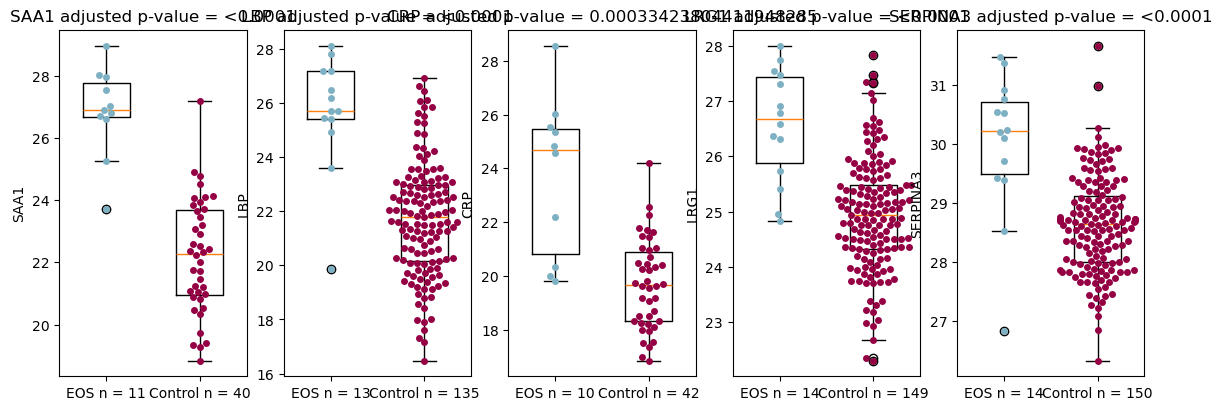

In [43]:
#testing for differences between each sample type for each protein without imputation

sns.set(font_scale=2)

plt.figure(figsize = [14,4.5])
plt.style.use('default')

genes = ['SAA1','LBP','CRP','LRG1','SERPINA3']
count = 0
pvals_list = []
for p in range(len(genes)):
    prot = genes[p]
    count += 1
    ax = plt.subplot(1,5,count)
    eos = new_df[new_df['sample_type']=='EOS'][prot].dropna()
    ctrl = new_df[new_df['sample_type']=='Control'][prot].dropna()
    ps = new_df[new_df['sample_type']=='PS'][prot].dropna()
    sns.swarmplot(eos, color = '#7cb0c2')
    sns.swarmplot(y = ctrl, x = 1, color = '#940043')
    ax.boxplot(eos, positions = [0], widths = 0.5, labels = ['EOS n = {}'.format(eos.shape[0])])
    ax.boxplot(ctrl, positions = [1], widths = 0.5, labels = ['Control n = {}'.format(ctrl.shape[0])])
    #ax.boxplot(ps, positions = [2], labels = ['PS n = {}'.format(ps.shape[0])])
    #jitters = np.random.normal(0 , 0.04, eos.shape[0])   
    #ax.scatter(jitters, eos, alpha = 0.75)

    #jitters = np.random.normal(1 , 0.04, ctrl.shape[0])   
    #ax.scatter(jitters, ctrl, alpha = 0.75)
    
    #jitters = np.random.normal(2 , 0.04, ps.shape[0])   
    #ax.scatter(jitters, ps, alpha = 0.75)
    pval = mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
    pvals_list.append(pval)
    if pval < 0.0001:
        pval = '<0.0001'
    ax.set_title('{} adjusted p-value = {}'.format(prot, pval))
    
siggenes = list(compress(genes, multipletests(pvals_list, method = 'fdr_bh')[0]))
tmp = multipletests(pvals_list, method = 'fdr_bh')
plt.savefig('graphs/fig2_boxplot_5prot.eps',format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [44]:
#save extended data file
f2c_data = new_df[['sample_type', 'sample_id'] + genes]
f2c_data.to_csv('extendeddata/f2c_data.csv', index=False)

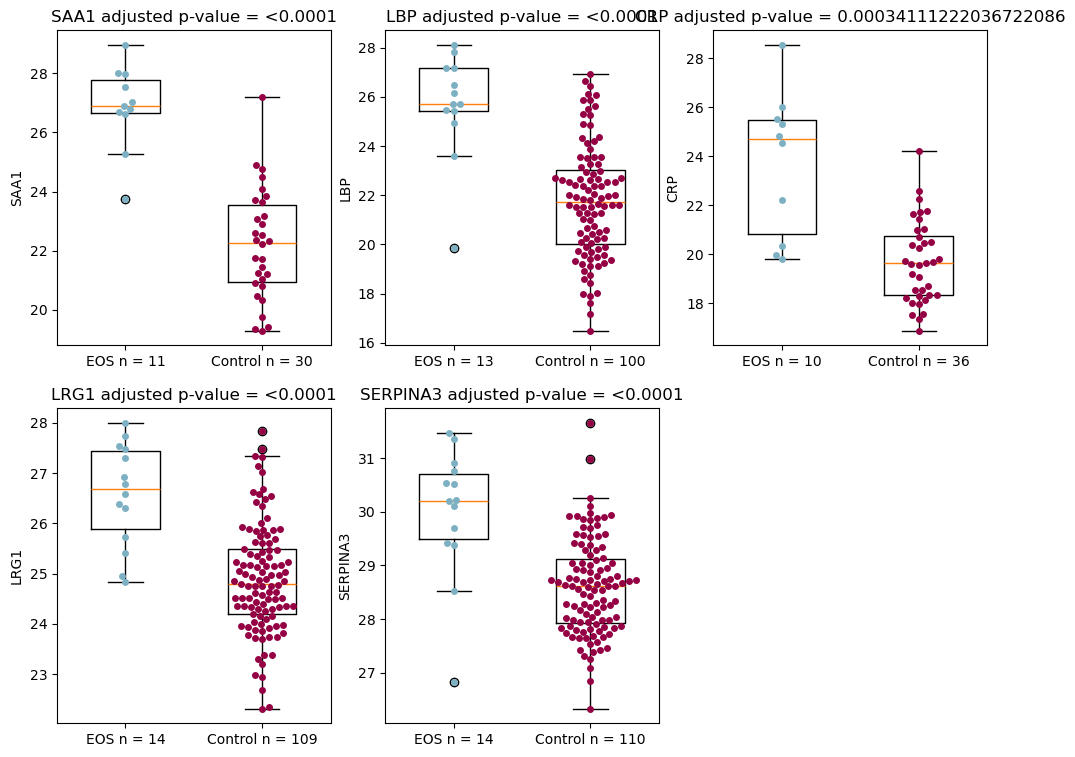

In [45]:
#testing for differences between each sample type for each protein without imputation: just the premature ones

sns.set(font_scale=2)

plt.figure(figsize = [12,9])
plt.style.use('default')
subset_df = new_df[new_df['GA_wks'] < 37]

genes = ['SAA1','LBP','CRP','LRG1','SERPINA3']
count = 0
pvals_list = []
for p in range(len(genes)):
    prot = genes[p]
    count += 1
    ax = plt.subplot(2,3,count)
    eos = subset_df[subset_df['sample_type']=='EOS'][prot].dropna()
    ctrl = subset_df[subset_df['sample_type']=='Control'][prot].dropna()
    ps = subset_df[subset_df['sample_type']=='PS'][prot].dropna()
    sns.swarmplot(eos, color = '#7cb0c2')
    sns.swarmplot(y = ctrl, x = 1, color = '#940043')
    ax.boxplot(eos, positions = [0], widths = 0.5, labels = ['EOS n = {}'.format(eos.shape[0])])
    ax.boxplot(ctrl, positions = [1], widths = 0.5, labels = ['Control n = {}'.format(ctrl.shape[0])])
    #ax.boxplot(ps, positions = [2], labels = ['PS n = {}'.format(ps.shape[0])])
    #jitters = np.random.normal(0 , 0.04, eos.shape[0])   
    #ax.scatter(jitters, eos, alpha = 0.75)

    #jitters = np.random.normal(1 , 0.04, ctrl.shape[0])   
    #ax.scatter(jitters, ctrl, alpha = 0.75)
    
    #jitters = np.random.normal(2 , 0.04, ps.shape[0])   
    #ax.scatter(jitters, ps, alpha = 0.75)
    pval = mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
    pvals_list.append(pval)
    if pval < 0.0001:
        pval = '<0.0001'
    ax.set_title('{} adjusted p-value = {}'.format(prot, pval))
    
siggenes = list(compress(genes, multipletests(pvals_list, method = 'fdr_bh')[0]))
tmp = multipletests(pvals_list, method = 'fdr_bh')
plt.savefig('graphs/sup2_boxplot_5prot.eps',format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [46]:
#save extended data file
s2b_data = subset_df[['sample_type', 'sample_id'] + genes]
s2b_data.to_csv('extendeddata/s2b_data.csv', index=False)


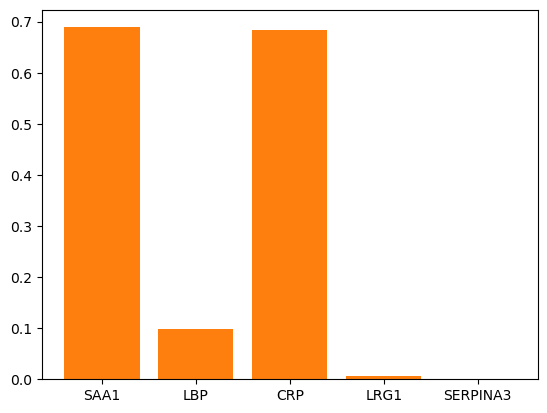

In [48]:
# visualize missingness of our five
missingness = new_df.loc[:,['SAA1','LBP','CRP','LRG1','SERPINA3']].isnull().sum()/new_df.shape[0]

plt.bar(x = missingness.index, height = missingness.values)
plt.show()
plt.close()

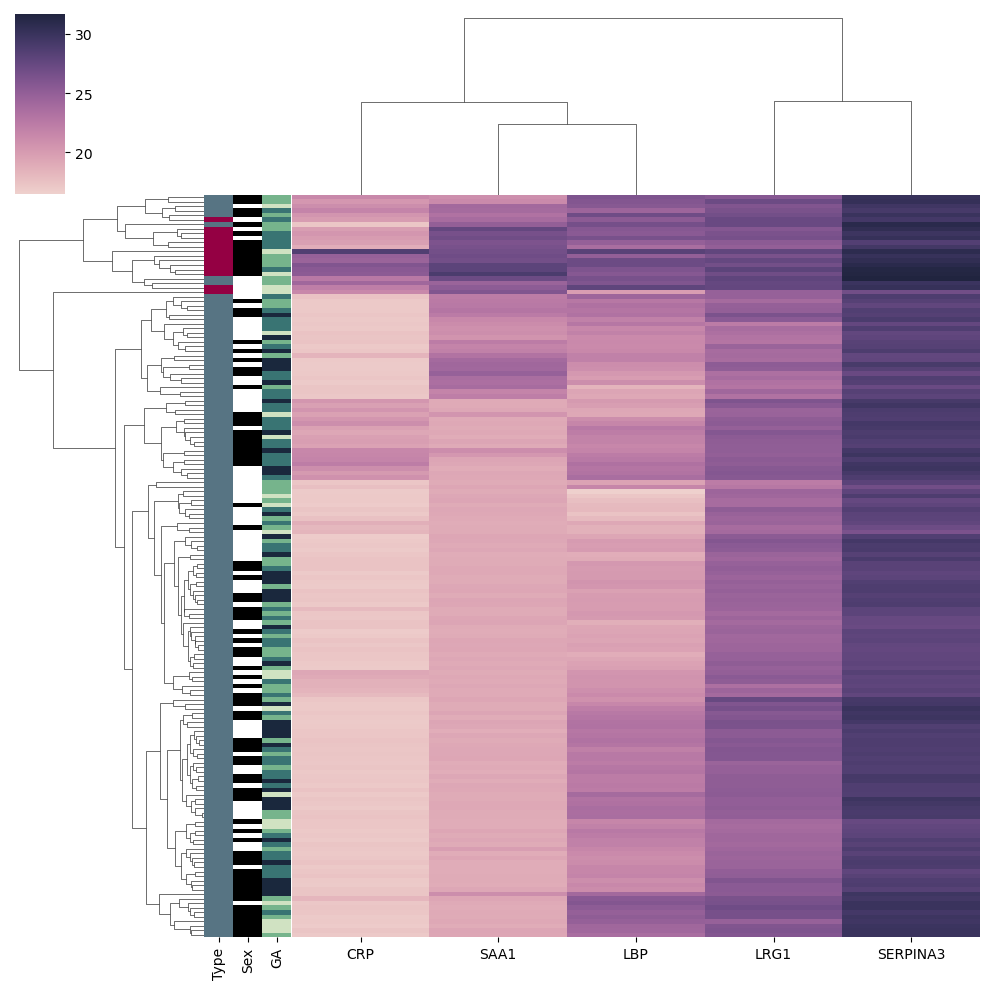

In [49]:
#creating a heatmap and clustering by proteins and samples to see if there are trends associated with sample type, sex or GA weeks
lut = {'EOS': '#940043', 'Control': '#577483', 'PS': '#f4bb3a'}
fourcol= sns.cubehelix_palette(start=3, rot=-.5, as_cmap=False, n_colors=4) #start =0.5 for pleasant blue, 
lut_ga = {'<28': fourcol[0], '28- <32': fourcol[1], '32-36': fourcol[2], '>=37': fourcol[3], None:'lightpink'}
lut_sex = {'Female': 'white', 'Male': 'black', None:'lightpink'}

imputeddf_prot = new_df_imp.loc[:,['SAA1','LBP','CRP','LRG1','SERPINA3']]

row_colors_ga = new_df_imp.loc[imputeddf_prot.index,'ga_cat'].map(lut_ga)
row_colors_sex = new_df_imp.loc[imputeddf_prot.index,'sex'].map(lut_sex)
#imputeddf_prot = imputeddf.loc[:,['SAA1','LBP','CRP','LRG1','SERPINA3']]
#row_colors_ga = new_df.loc[imputeddf_prot.index,'ga_cat'].map(lut_ga)
#row_colors_sex = new_df.loc[imputeddf_prot.index,'sex'].map(lut_sex)


lab_list = [imputed_labels]
data_list = [imputeddf_prot]
lab = lab_list[0]
data = data_list[0]
row_colors = lab.map(lut)

row_colors_combined = pd.DataFrame({
    'Type': row_colors,
    'Sex': row_colors_sex,
    'GA': row_colors_ga
})

testt = sns.cubehelix_palette(start =-0.3, rot=0.5, as_cmap=True, reverse=False)#0.3 for nice purp

sns.clustermap(data, figsize = [10,10],cmap = testt, yticklabels = False,col_cluster = True, row_colors=row_colors_combined)
plt.savefig('graphs/fig2_clustermap.eps', format = 'eps', bbox_inches = 'tight')
plt.show()
plt.close()

In [50]:
f2b_data = imputeddf_prot.copy()
f2b_data['sample_type'] = lab
f2b_data['sample_id'] = new_df_imp.loc[imputeddf_prot.index,'sample_id']
f2b_data['ga_cat'] = new_df_imp.loc[imputeddf_prot.index,'ga_cat']
f2b_data['sex'] = new_df_imp.loc[imputeddf_prot.index,'sex']
f2b_data.to_csv('extendeddata/f2b_data.csv', index=False)


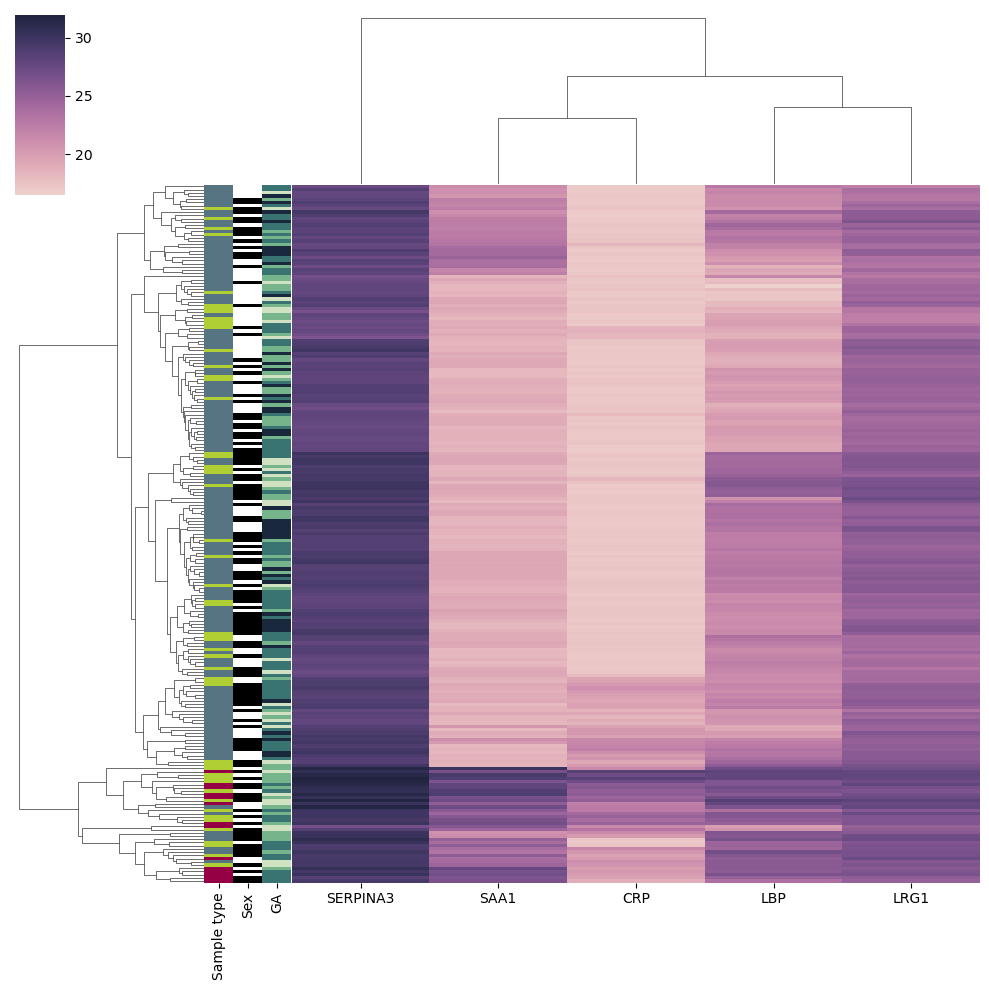

In [55]:
# supp fig 5. Heatmap of the 5 differentially abundant proteins with presumed sepsis in there too.
# imputing values for heatmap visualizations (which do not play nice with NAs)
# first: for proteins with less than 30% missingness, use an iterative imputer by sample type
# then: for proteins with greater missingness, just sample from the bottom 10% of values
# the rationale for this approach is that since most missing proteins arose from batch effects,
#   and the batches are 25% each, so proteins with >25-30% missingness are most likely truly non-abundant
#   rather than just not detected in a given batch.
#removing proteins that have over 80% missingness
#removing all the controls and presumed sepsis patients
new_df2 = pd.read_csv('data/leena_proteins_mean2023_nu037fix.csv', index_col = 0) # reshaped dataframe w/ rows for each sample & cols for each protein + some clinical variables
merge_df = df.loc[:,['sex','sample_id']]
merge_df = merge_df.drop_duplicates()
new_df2['sample_id'] = new_df2.index
new_df2 = pd.merge(new_df2, merge_df, how = 'left', on = 'sample_id')
new_df2 = new_df2.drop(new_df2[(new_df2['sample_id'] == 'NU037') & (new_df2['sex'].isna())].index, axis=0)
new_df2 = new_df2[(new_df2['sample_type'] != 'PS') | (new_df2['sample_id'].isin(ps_relevant))]
new_df2 = new_df2[new_df2['sample_type'] != 'PS_nonclassicEOS']
new_df2 = new_df2[new_df2['sample_type'] != 'nonclassicEOS']
new_df2 = new_df2[new_df2['sample_type'] != 'Control + degradation assessment sample']
new_df2 = new_df2[new_df2['sample_type'] != 'PS_nonclassic EOS']
new_df2 = new_df2[new_df2['sample_type'] != 'pooled_control']
#new_df2 = new_df2[new_df2['sample_type'] != 'PS']
tmp = new_df2.isnull().sum()/new_df2.shape[0]
new_df2 =  new_df2.drop(tmp[tmp>0.80].index, axis = 1)
new_df_imp2 = new_df2.copy() #copy it
imputeddf2= pd.DataFrame() # this is to save just the imputed things
imp = IterativeImputer(max_iter=10, random_state=0) #define iterative imputer funxion

for st in ['EOS','Control', 'PS']: #do the following for each sample type:
    tmp = new_df2[new_df2['sample_type'] == st] #store in tmp only the rows in new_df that have the current sample type
    vals =  tmp.iloc[:, :-7] # grab all cols except the last seven! which are metadata.
    missing = vals.isnull().sum()/vals.shape[0] #for each column, what % are missing?
    keep = missing[missing<0.3].index # names of columns (proteins) where they mostly aren't missing.
    vals_imp = imp.fit_transform(vals.loc[:,keep]) # for the proteins in keep, impute
    vals_imp = pd.DataFrame(vals_imp, index = vals.index, columns = keep) #make it a dataframe
    new_df_imp2.loc[vals_imp.index, vals_imp.columns] = vals_imp
    imputeddf2 = pd.concat([imputeddf2, vals_imp]) # save just the imputed things
imputed_labels2 = new_df2.loc[new_df_imp2.index, 'sample_type']
imputed_sampleid2 = new_df2.loc[new_df_imp2.index, 'sample_id']

#imputing missing values by sampling from bottom 10% of values per protein for proteins not previously dealt with
for prot in new_df2.columns[:-7]:
    if not new_df2[prot].isnull().any(): 
        continue 
    quantile = new_df2[prot].quantile(0.05)
    min_val = new_df2[new_df2[prot]<quantile][prot].min()
    max_val = new_df2[new_df2[prot]<quantile][prot].max()
    for idx in new_df_imp2[new_df_imp2[prot].isnull()][prot].index:
        sample = random.uniform(min_val, max_val) #bottom 10% 
        #sample = 0
        new_df_imp2.at[idx,prot] = sample
        imputeddf2.at[idx,prot] = sample

#creating a heatmap and clustering by proteins and samples to see if there are trends associated with sample type, sex or GA weeks
lut = {'EOS': '#940043', 'Control': '#577483', 'PS': '#f4bb3a'}
fourcol= sns.cubehelix_palette(start=3, rot=-.5, as_cmap=False, n_colors=4) #start =0.5 for pleasant blue, 
lut_ga = {'<28': fourcol[0], '28- <32': fourcol[1], '32-36': fourcol[2], '>=37': fourcol[3], None:'lightpink'}
lut_sex = {'Female': 'white', 'Male': 'black', None:'lightpink'}

imputeddf_prot = new_df_imp2.loc[:,['SAA1','LBP','CRP','LRG1','SERPINA3']]

row_colors_ga = new_df_imp2.loc[imputeddf_prot.index,'ga_cat'].map(lut_ga)
row_colors_sex = new_df_imp2.loc[imputeddf_prot.index,'sex'].map(lut_sex)
#imputeddf_prot = imputeddf.loc[:,['SAA1','LBP','CRP','LRG1','SERPINA3']]
#row_colors_ga = new_df.loc[imputeddf_prot.index,'ga_cat'].map(lut_ga)
#row_colors_sex = new_df.loc[imputeddf_prot.index,'sex'].map(lut_sex)


lab = imputed_labels2  # this is your sample_type column (EOS, Control, PS)
data = imputeddf_prot

lut = {'EOS': '#940043', 'Control': '#577483', 'PS': '#b0cf35'}  # define this properly

row_colors_sample_type = lab.map(lut)

row_colors_combined = pd.DataFrame({
    'Sample type': row_colors_sample_type,
    'Sex': row_colors_sex,
    'GA': row_colors_ga
})

testt = sns.cubehelix_palette(start =-0.3, rot=0.5, as_cmap=True, reverse=False)#0.3 for nice purp

sns.clustermap(data, figsize = [10,10],cmap = testt, yticklabels = False,col_cluster = True, row_colors=row_colors_combined)
plt.savefig('graphs/supfig5_clustermap.eps', format = 'eps', bbox_inches = 'tight')
plt.show()
plt.close()

In [56]:
s5_data = imputeddf_prot.copy()
s5_data['sample_type'] = lab
s5_data['sample_id'] = new_df_imp2.loc[imputeddf_prot.index,'sample_id']
s5_data['ga_cat'] = new_df_imp2.loc[imputeddf_prot.index,'ga_cat']
s5_data['sex'] = new_df_imp2.loc[imputeddf_prot.index,'sex']
s5_data.to_csv('extendeddata/s5_data.csv', index=False)

In [54]:
pd.Series(new_df_imp2['ga_cat']).value_counts()


ga_cat
32-36      83
28- <32    61
>=37       40
<28        33
Name: count, dtype: int64

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


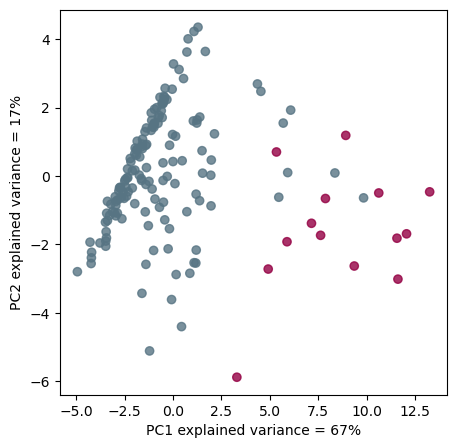

In [58]:
#creating a PCA plot to show if the sample types cluster together
imputeddf_prot = new_df_imp.loc[:, ['SAA1', 'LBP', 'CRP', 'LRG1', 'SERPINA3']]
imputed_labels = new_df_imp['sample_type']

plt.figure(figsize=(5, 5))
pca = PCA(n_components=2)
x_new = pca.fit_transform(imputeddf_prot)
row_colors = imputed_labels.map(lut)

y = row_colors
plt.scatter(x_new[:,0], x_new[:,1], color = row_colors, alpha = 0.8)
plt.xlabel('PC1 explained variance = {}%'.format(int(pca.explained_variance_ratio_[0]*100)))
plt.ylabel('PC2 explained variance = {}%'.format(int(pca.explained_variance_ratio_[1]*100)))
plt.savefig('graphs/fig2_pca.eps', bbox_inches = 'tight')
plt.show()


In [59]:
f2a_data = pd.DataFrame(
    data=x_new,
    columns=['PC1', 'PC2']  
)
f2a_data['sample_type'] = new_df_imp['sample_type'].values
f2a_data['sample_id'] = new_df_imp['sample_id'].values

f2a_data.to_csv('extendeddata/f2a_data.csv', index=False)


In [ ]:
### Figure 3.

In [257]:
# first, process mesoscale data
mesoscale = pd.read_excel('data/cord_mesoscaledata_12_9_22.xlsx', engine='openpyxl')
psmetadata = pd.read_csv('data/ps_metadata_cut.csv') # metadata for each sample

metadata = psmetadata
#idx = mesoscale[mesoscale['sample_id'].isin(metadata[metadata['epoch']==4]['sample_id'])].index
idx = mesoscale[mesoscale['sample_id'].isin(metadata[metadata['GA_wks']>=37]['sample_id'])].index
mesoscale = mesoscale.drop(idx, axis = 0)
metadata = metadata[metadata['GA_wks']<37]

#renaming column names
for c in ['SAA_avg_conc_pg/ml','CRP_avg_conc_pg/ml','LBP_avg_conc_pg/ml']:
    mesoscale = mesoscale.rename({c:c.split('/')[0]}, axis = 1)
    mesoscale['{}_log'.format(c.split('/')[0])] = np.log(mesoscale[c.split('/')[0]])

#pulling out the metadata keys
metadata_keys = metadata.iloc[0,:]


#dropping controls and other PS weird sample types
for drop in ['pooled_control','nonclassicEOS','Control + degradation assessment sample','PS_nonclassicEOS','PS_nonclassic EOS']:
    mesoscale = mesoscale[mesoscale['sample_type']!=drop]
    metadata = metadata[metadata['sample_type']!=drop]

for c in ['preeclampsia_gesthtn', 'deliverysum', 'route_of_del', 'labor',
       'clinicalchorio', 'PROM']:
#     print(metadata[metadata[c].isnull()])
    metadata[c] = metadata[c].astype(int)

#incorporating metadata into the main dataset
mesoscale = pd.merge(mesoscale, metadata, how = 'left', on = 'sample_id')
mesoscale = mesoscale[mesoscale['mesoscale_plate_number'].notnull()]

outliers = ['NU102', 'NU1260', 'NU435']
mesoscale_cut = mesoscale[~mesoscale['sample_id'].isin(outliers)]

#imputation of missing values with 0 due to mesoscales ultra sensitive characteristics

tmpdf = mesoscale.loc[:,['CRP_avg_conc_pg_log','SAA_avg_conc_pg_log', 'LBP_avg_conc_pg_log']].fillna(0)
tmpdf.index = mesoscale['sample_id']
mesoscale.index = mesoscale['sample_id']

lut = {'EOS': '#940043', 'Control': '#bae4e6', 'PS': '#f4bb3a'}
row_colors = mesoscale['sample_type_x'].map(lut)
testt = sns.cubehelix_palette(start =-0.3, rot=0.5, as_cmap=True, reverse=False)#0.3 for nice purp


In [258]:
# check how many samples are in mesoscale.
# depending on what you want, there should be 105-113 controls (105 if excluding GA >= 37 wks, 113 otherwise)
# and 11-14 EOS (3 outliers)
pd.Series(mesoscale['sample_type_x']).value_counts()

sample_type_x
Control    105
PS          53
EOS         14
Name: count, dtype: int64

In [87]:
# making other useful mesoscale derivatives.
mesoscale_reserve = mesoscale.copy()

# removing the outliers.
outliers = ['NU102', 'NU1260', 'NU435']
mesoscale_cut = mesoscale[~mesoscale['sample_id'].isin(outliers)]

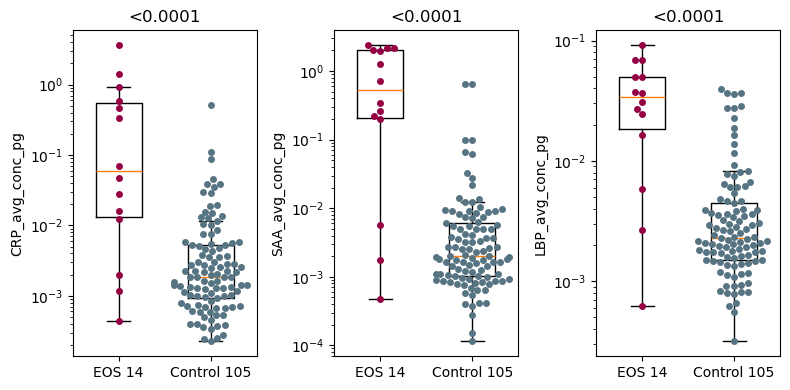

In [88]:
#boxplot of the 3 proteins split by cohort (control vs EOS)
sns.set(font_scale=2)
plt.style.use('default')

plt.figure(figsize = [8,4])
genes = ['CRP_avg_conc_pg',
'SAA_avg_conc_pg',
'LBP_avg_conc_pg']

ctrl_medians = {}
eos_medians = {}

count = 0
pvals_list = []
PG_TO_MG = 1e-9

for p in range(len(genes)):
    prot = genes[p]
    count += 1
    ax = plt.subplot(1,3,count)
    eos = (mesoscale[mesoscale['sample_type_x']=='EOS'][prot].dropna()) * PG_TO_MG
    ctrl = (mesoscale[mesoscale['sample_type_x']=='Control'][prot].dropna()) * PG_TO_MG
    ctrl_medians[prot] = ctrl.median()
    eos_medians[prot] = eos.median()

    sns.swarmplot(eos, color = '#940043')
    sns.swarmplot(y = ctrl, x = 1, color = '#577483')    
    ax.boxplot(eos, positions = [0], widths = 0.5, labels = ['EOS {}'.format(eos.shape[0])], showfliers = False)
    ax.boxplot(ctrl, positions = [1], widths = 0.5, labels = ['Control {}'.format(ctrl.shape[0])], showfliers = False)
    #jitters = np.random.normal(0 , 0.04, eos.shape[0])   
    #ax.scatter(jitters, eos, alpha = 0.75, color = 'r')

    #jitters = np.random.normal(1 , 0.04, ctrl.shape[0])   
    #ax.scatter(jitters, ctrl, alpha = 0.75, color = 'b')
    plt.yscale('log')

    pval = mann_whitneypval = stats.mannwhitneyu(eos, ctrl).pvalue
    pvals_list.append(pval)
    if pval < 0.0001:
        pval = '<0.0001'
    ax.set_title('{}'.format(pval))


# siggenes = list(compress(genes, multipletests(pvals_list, method = 'fdr_bh')[0]))
tmp = multipletests(pvals_list, method = 'fdr_bh')
plt.tight_layout()

plt.savefig('graphs/fig3_msd_beeswarms_log.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

In [74]:
f3b_dataa = mesoscale[mesoscale['sample_type_x']!='PS']
f3b_data = f3b_dataa[['sample_type_y', 'sample_id'] + genes].copy()
#f3b_dataa[genes] = f3b_dataa[genes] * PG_TO_MG
f3b_data.to_csv('extendeddata/f3b_data.csv', index=False)


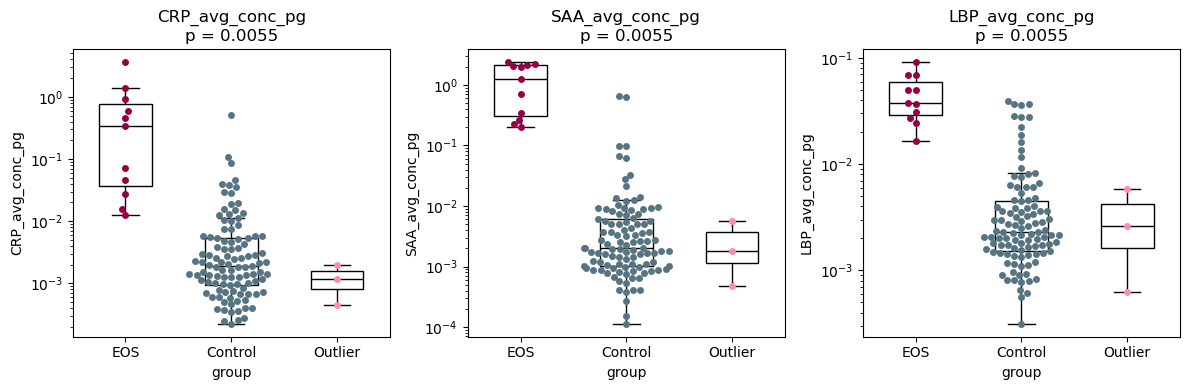

In [70]:
outliers = ['NU102', 'NU1260', 'NU435']
PG_TO_MG = 1e-9
genes = ['CRP_avg_conc_pg', 'SAA_avg_conc_pg', 'LBP_avg_conc_pg']

# Prepare dataframe
df = mesoscale[['sample_id', 'sample_type_x'] + genes].copy()
df['group'] = df['sample_type_x']
df.loc[df['sample_id'].isin(outliers), 'group'] = 'Outlier'

# Set colors
group_palette = {
    'Control': '#577483',
    'EOS': '#940043',
    'Outlier': '#ff8ab7'
}

sns.set(font_scale=2)
plt.style.use('default')
plt.figure(figsize=[12, 4])

pvals_list = []

for i, prot in enumerate(genes):
    ax = plt.subplot(1, 3, i+1)
    df_plot = df[['group', prot]].dropna().copy()
    df_plot[prot] *= PG_TO_MG

    # Transparent boxplot
    sns.boxplot(
        data=df_plot,
        x='group',
        y=prot,
        order=['EOS', 'Control', 'Outlier'],
        showfliers=False,
        width=0.5,
        boxprops=dict(facecolor='none', edgecolor='black'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markerfacecolor='black', alpha=0.5),
        ax=ax
    )

    # Colored swarmplot
    for group in ['EOS', 'Control', 'Outlier']:
        group_data = df_plot[df_plot['group'] == group]
        sns.swarmplot(
            x=[group] * len(group_data),
            y=group_data[prot],
            color=group_palette[group],
            ax=ax
        )

    # Log scale
    ax.set_yscale('log')

    # Mann-Whitney p-value between EOS and Control
    eos_vals = df_plot[df_plot['group'] == 'Outlier'][prot]
    ctrl_vals = df_plot[df_plot['group'] == 'EOS'][prot]
    pval = stats.mannwhitneyu(eos_vals, ctrl_vals).pvalue
    pvals_list.append(pval)
    ax.set_title(f'{prot}\np = {"<0.0001" if pval < 0.0001 else round(pval, 4)}')

plt.tight_layout()
plt.savefig('graphs/fig3_msd_beeswarms_log_with_outliers_transparent_box.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()


In [75]:
s3_data = df[['sample_type_x', 'sample_id', 'group'] + genes].copy()
#s3_data[genes] = s3_data[genes] * PG_TO_MG
s3_data.to_csv('extendeddata/s3_data.csv', index=False)

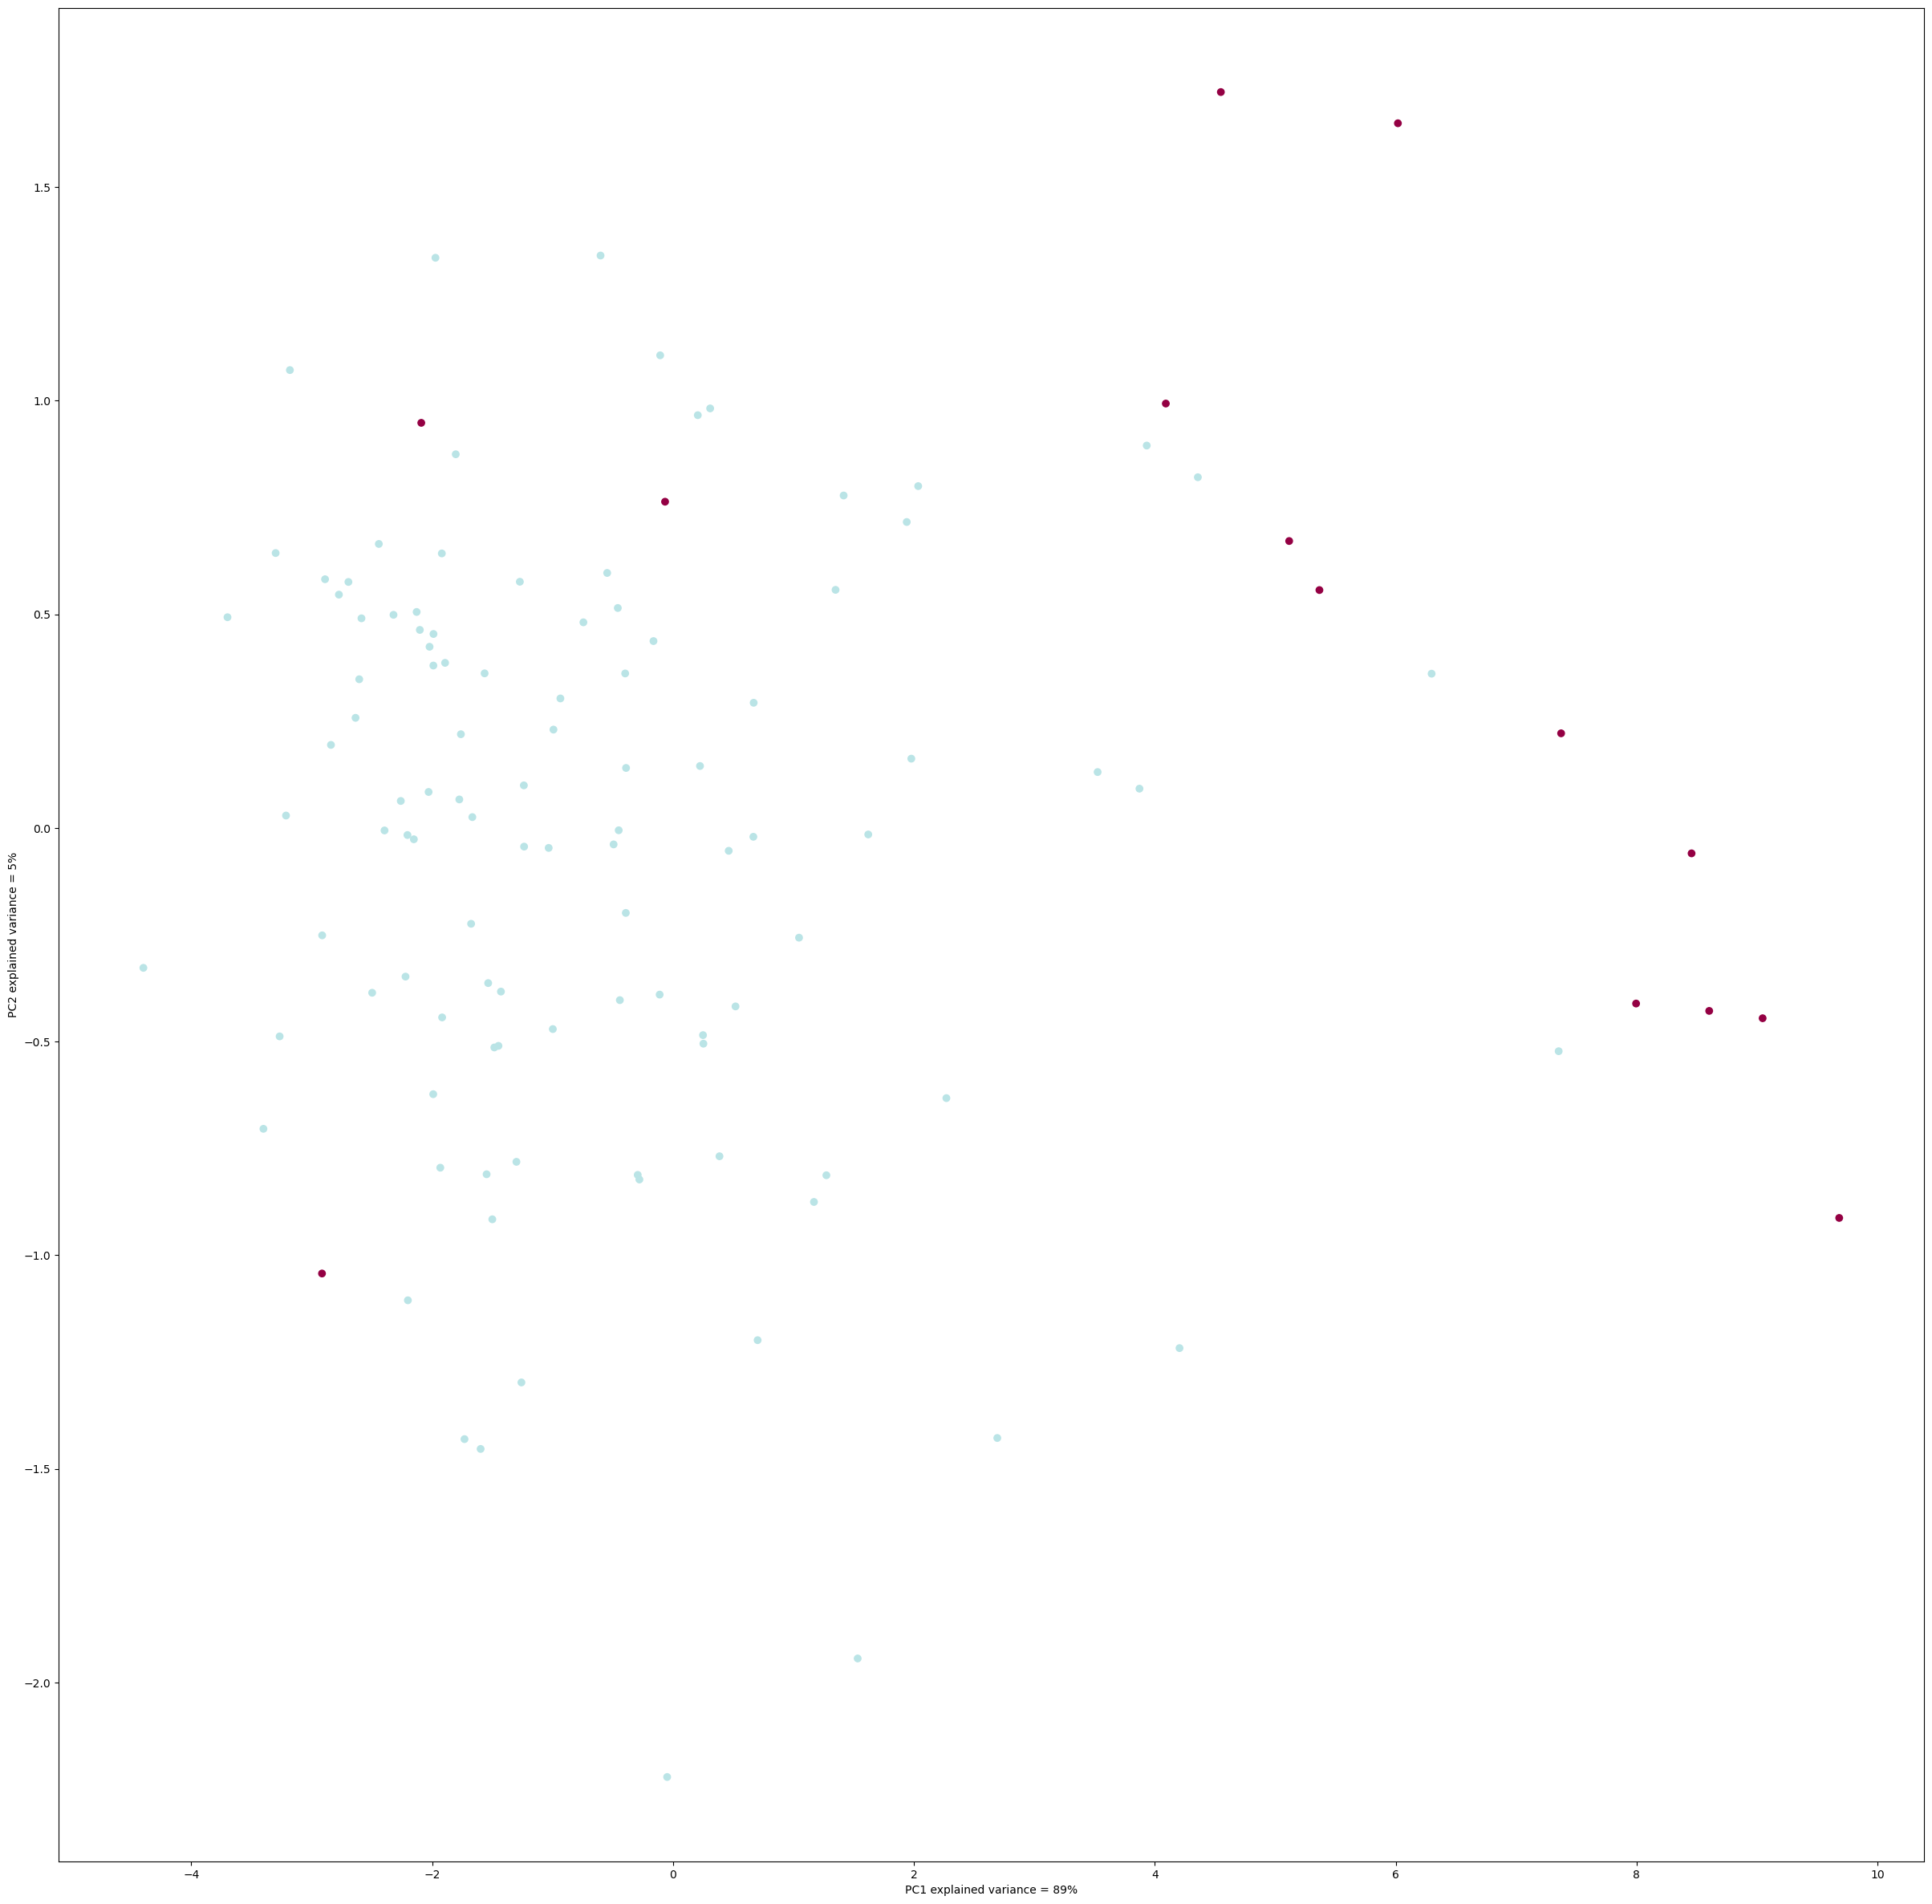

In [76]:
#PCA plot of just the eos/control
ok = ['EOS', 'Control']
sample_ids = mesoscale[mesoscale['sample_type_x'].isin(ok)]['sample_id'].tolist()

#plottem = x_new_df[x_new_df['sample_id'].isin(sample_ids)]
#plottem = x_new_df[x_new_df.index.isin(ok)]

interest = tmpdf[tmpdf.index.isin(sample_ids)]

sns.set(font_scale=2)

plt.figure(figsize = [30,30])
plt.style.use('default')
pca = PCA(n_components=2)
x_new = pca.fit_transform(interest)
x_new_df = pd.DataFrame(x_new)
x_new_df.index = interest.index

filtered_colors = [row_colors[list(tmpdf.index).index(idx)] for idx in interest.index]

plt.scatter(x_new_df.iloc[:,0], x_new_df.iloc[:,1], color = filtered_colors)
plt.xlabel('PC1 explained variance = {}%'.format(int(pca.explained_variance_ratio_[0]*100)))
plt.ylabel('PC2 explained variance = {}%'.format(int(pca.explained_variance_ratio_[1]*100)))


plt.savefig('graphs/fig3_pca.eps',format = 'eps',bbox_inches = 'tight')
plt.show()
plt.close()

In [77]:
f3c_data = x_new_df.copy()
f3c_data['sample_id'] = f3c_data.index
f3c_data['sample_type'] = mesoscale.set_index('sample_id').loc[f3c_data.index, 'sample_type_x']
f3c_data.to_csv('extendeddata/f3c_data.csv', index=True)


In [ ]:
### Figure 4.

In [53]:
# Logistic regressions

import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score


mesoscale_nops = mesoscale[mesoscale['sample_type_x']!='PS']
mesoscale_nops = mesoscale_nops.dropna(subset=['sex'])
mesoscale_nops['sex'] = mesoscale_nops['sex'].astype(int)

mesoscale_nops = mesoscale_nops.dropna(subset=['sex'])
mesoscale_nops['sex'] = mesoscale_nops['sex'].astype(int)

mesoscale_nops['sample_type_x'] = mesoscale_nops['sample_type_x'].map({'EOS':1, 'Control':0})
outliers = ['NU102', 'NU1260', 'NU435']
mesoscale_nops = mesoscale_nops[~mesoscale['sample_id'].isin(outliers)]
def calculate_classification_metrics(y_true, y_pred):
    """Calculate accuracy, sensitivity, and specificity."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)  # Also known as recall
    specificity = tn / (tn + fp)
    
    return accuracy, sensitivity, specificity, tp, fp, tn, fn

# Define the features
cat = ['SAA_avg_conc_pg', 'LBP_avg_conc_pg', 'CRP_avg_conc_pg', 'sex', 'preeclampsia_gesthtn', 'deliverysum', 'multiplegest', 'PROM', 'clinicalchorio', 
       'labor', 'route_of_del', 'Concentration_ug_uL']
# Initialize an empty list to store results
results_list = []
from sklearn.metrics import precision_score, f1_score

# Run logistic regression for each feature
for feature in cat:
    # Create the formula
    formula = f'sample_type_x ~ GA_wks + sex + {feature}'
    #formula = f'sample_type_x ~ GA_wks + sex'
    
    try:
        # Fit the model
        model = smf.logit(formula, data=mesoscale_nops)
        result = model.fit(disp=False)
        
        # Get predicted probabilities
        y_pred_proba = result.predict(mesoscale_nops)
        # Convert probabilities to binary predictions using 0.5 threshold
        y_pred = (y_pred_proba >= 0.5).astype(int)
        # Get true values
        y_true = mesoscale_nops['sample_type_x']
        
        # Calculate classification metrics
        accuracy, sensitivity, specificity, tp, fp, tn, fn = calculate_classification_metrics(y_true, y_pred)
        auc = roc_auc_score(y_true, y_pred_proba)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        
        # Store results in a dictionary
        result_dict = {
            'feature': feature,
            'formula': formula,
            'AIC': result.aic,
            'BIC': result.bic,
            'log_likelihood': result.llf,
            'pseudo_r2': result.prsquared,
            'converged': result.mle_retvals['converged'],
            'accuracy': accuracy,
            'recall': recall,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'fpr': fpr,
            'f1': f1,
            'auc': auc,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn
        }
        ga_val = 30
        sex_val = 0

        params = result.params
        logit_val = -(params['Intercept'] + params['GA_wks'] * ga_val + params['sex'] * sex_val)
        saa_cutoff = logit_val / params[feature]
        print(f"{feature} cutoff (P=0.5): {saa_cutoff:.2f}")
        results_list.append(result_dict)
        
    except Exception as e:
        print(f"Error fitting model for feature {feature}: {str(e)}")


all_results = pd.DataFrame(results_list)
numeric_columns = ['AIC', 'BIC', 'log_likelihood', 'pseudo_r2', 
                   'accuracy', 'recall', 'specificity', 'sensitivity', 'precision', 
                   'fpr', 'f1', 'auc']
all_results[numeric_columns] = all_results[numeric_columns].round(3) #round

all_results.to_csv('data/summary_onefeature.csv', index=False)

print("\nSummary of Classification Metrics:")
print(all_results[['feature', 'accuracy', 'sensitivity', 'specificity']].describe())

SAA_avg_conc_pg cutoff (P=0.5): 521676083.52
LBP_avg_conc_pg cutoff (P=0.5): 36297303.66
CRP_avg_conc_pg cutoff (P=0.5): 350920745.08
sex cutoff (P=0.5): -3.51
preeclampsia_gesthtn cutoff (P=0.5): -0.06
deliverysum cutoff (P=0.5): -0.48
multiplegest cutoff (P=0.5): -2.80
PROM cutoff (P=0.5): 1.18
clinicalchorio cutoff (P=0.5): 0.60
labor cutoff (P=0.5): 1.07
route_of_del cutoff (P=0.5): -0.42
Concentration_ug_uL cutoff (P=0.5): -32.65

Summary of Classification Metrics:
        accuracy  sensitivity  specificity
count  12.000000    12.000000    12.000000
mean    0.917333     0.181833     0.994333
std     0.018337     0.274074     0.009614
min     0.905000     0.000000     0.971000
25%     0.905000     0.000000     0.990000
50%     0.905000     0.000000     1.000000
75%     0.940000     0.455000     1.000000
max     0.948000     0.636000     1.000000


In [54]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

# Define function for classification metrics
def calculate_classification_metrics(y_true, y_pred):
    """Calculate accuracy, sensitivity, and specificity."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)  # Recall
    specificity = tn / (tn + fp)
    return accuracy, sensitivity, specificity, tp, fp, tn, fn

# Define more complex models
model_formulas = {
    "Model_1": "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + clinicalchorio + multiplegest + labor",
    "Model_2": "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + clinicalchorio + multiplegest + route_of_del",
    "Model_3": "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + PROM + multiplegest + labor",
    "Model_4": "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + PROM + multiplegest + route_of_del",
    'Model_5': "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + CRP_avg_conc_pg + LBP_avg_conc_pg + PROM + multiplegest + route_of_del",
    'Model_6': "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + CRP_avg_conc_pg + LBP_avg_conc_pg + clinicalchorio + multiplegest + route_of_del",
    'Model_7': "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + CRP_avg_conc_pg + LBP_avg_conc_pg + PROM + multiplegest + labor",
    'Model_8': "sample_type_x ~ GA_wks + sex + SAA_avg_conc_pg + CRP_avg_conc_pg + LBP_avg_conc_pg + clinicalchorio + multiplegest + labor",
    'Model_9': "sample_type_x ~ GA_wks + sex + clinicalchorio + multiplegest + labor"
}

# Store results
results_list = []

# Run logistic regression for each formula
for model_name, formula in model_formulas.items():
    try:
        model = smf.logit(formula, data=mesoscale_nops)
        result = model.fit(disp=False)

        # Get predicted probabilities
        y_pred_proba = result.predict(mesoscale_nops)
        # Convert probabilities to binary predictions using 0.5 threshold
        y_pred = (y_pred_proba >= 0.5).astype(int)
        # Get true values
        y_true = mesoscale_nops['sample_type_x']
        
        # classification metrics
        accuracy, sensitivity, specificity, tp, fp, tn, fn = calculate_classification_metrics(y_true, y_pred)
        auc = roc_auc_score(y_true, y_pred_proba)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        # store results
        result_dict = {
            'model': model_name,
            'formula': formula,
            'AIC': result.aic,
            'BIC': result.bic,
            'log_likelihood': result.llf,
            'pseudo_r2': result.prsquared,
            'converged': result.mle_retvals['converged'],
            'accuracy': accuracy,
            'recall': recall,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'fpr': fpr,
            'f1': f1,
            'auc': auc,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn
        }
        
        results_list.append(result_dict)
        
    except Exception as e:
        print(f"Error fitting model {model_name}: {str(e)}")

# convert results to df
all_results = pd.DataFrame(results_list)
numeric_columns = ['AIC', 'BIC', 'log_likelihood', 'pseudo_r2', 
                   'accuracy', 'sensitivity', 'specificity', 'auc']
all_results[numeric_columns] = all_results[numeric_columns].round(3)  # round

# save
all_results.to_csv('data/summary_multifeature.csv', index=False)

print("\nSummary of Classification Metrics:")
print(all_results[['model', 'accuracy', 'sensitivity', 'specificity']].describe())



Summary of Classification Metrics:
       accuracy  sensitivity  specificity
count  9.000000     9.000000     9.000000
mean   0.968444     0.777667     0.988000
std    0.011215     0.121000     0.003969
min    0.940000     0.455000     0.981000
25%    0.966000     0.818000     0.990000
50%    0.974000     0.818000     0.990000
75%    0.974000     0.818000     0.990000
max    0.974000     0.818000     0.990000


In [198]:
# Random forests downstream...
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import StratifiedKFold

from sklearn.inspection import permutation_importance

import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels
from scipy.stats import mannwhitneyu, wilcoxon
import itertools
from sklearn.preprocessing import StandardScaler
from numpy import inf
import math
from statsmodels.stats.multitest import multipletests
from matplotlib.pyplot import cm
from sklearn.cluster import AgglomerativeClustering
from itertools import combinations

import sys
#from tqdm import tqdm
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

In [169]:
#filtering out the presumed sepsis group
ps_notlab = mesoscale[(mesoscale['sample_type_y']=='PS')]

ps_notlab = ps_notlab[ps_notlab['CRP_avg_conc_pg'].notnull()]

In [170]:
pd.Series(mesoscale['sample_type_y']).value_counts()


sample_type_y
Control    105
PS          53
EOS         14
Name: count, dtype: int64

In [201]:
SEED = 204
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


#training a random forest model to classify EOS vs Control using the mesoscale data
#10 total runs with 50% training, 50% testing data.
#50% training data is further subjected to gridsearch cross validation to get the best model
f1_list = []
tpr_list = []
fpr_list = []
roc_list = []
precision_list = []
recall_list = []
tp_list = []
fp_list = []
tn_list = []
fn_list = []

df = mesoscale[(mesoscale['sample_type_y']=='Control') | (mesoscale['sample_type_y']=='EOS') ]
df = df[df['CRP_avg_conc_pg'].notnull()]

outliers = ['NU102', 'NU1260', 'NU435']
df = df[~df['sample_id'].isin(outliers)]
df['sample_type_y'].value_counts()
print(pd.Series(df['sample_type_y']).value_counts())
ps_notlab = mesoscale[(mesoscale['sample_type_y']=='PS')]
psmissing = ps_notlab[ps_notlab['CRP_avg_conc_pg'].isnull()]
ps_notlab = ps_notlab[ps_notlab['CRP_avg_conc_pg'].notnull()]
ps = mesoscale[(mesoscale['sample_type_y']=='PS')].loc[:,['CRP_avg_conc_pg','SAA_avg_conc_pg', 'LBP_avg_conc_pg']]

Xbio = df.loc[:,['CRP_avg_conc_pg','SAA_avg_conc_pg', 'LBP_avg_conc_pg', 'GA_wks', 'sex', 'multiplegest', 'preeclampsia_gesthtn', 'route_of_del', 'labor', 'deliverysum', 'clinicalchorio', 'PROM', 'Concentration_ug_uL']]
Xclin = df.loc[:,['GA_wks', 'sex', 'multiplegest', 'preeclampsia_gesthtn', 'route_of_del', 'labor', 'clinicalchorio', 'deliverysum', 'PROM', 'Concentration_ug_uL']]
Y = df['sample_type_y']

# function to train and evaluate the model
def train_rf(X, Y, seedy):
    f1_list, tpr_list, fpr_list, roc_list, precision_list, recall_list, f1_listbin, f1_listmacro, f1_listweighted, f1_listsamples = [], [], [], [], [], [], [], [], [], []
    models = []
    permutation_importance_list = [] #new
    
    sss = StratifiedShuffleSplit(n_splits=10, test_size=0.5, random_state=seedy)
    for train_index, test_index in sss.split(X, Y):
        rf = RandomForestClassifier(class_weight={'EOS': 10, 'Control': 1}, random_state=seedy)
        parameters = {
            'n_estimators': [50, 100],
            'max_features': ['sqrt', 'log2'],
            'criterion': ['gini', 'entropy'],
            'max_depth': [4, 5, 6],
            'min_samples_leaf': [2, 3]
        }
        cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seedy)
        print('im going into the gridsearch')
        clf = GridSearchCV(rf, parameters, cv=cv_inner)
        clf.fit(X.iloc[train_index, :], Y.iloc[train_index])
        print('im done gridsearching')
        models.append(clf)
        y_pred = clf.predict(X.iloc[test_index, :])
        y_pred_probab = clf.predict_proba(X.iloc[test_index, :])[:, 1]
        y_true = Y.iloc[test_index]
        
        # Calculate metrics
        #f1_list.append(f1_score(y_true, y_pred, average='micro'))
        f1_listbin.append(f1_score(y_true, y_pred, average='binary', pos_label='EOS'))
        #f1_listmacro.append(f1_score(y_true, y_pred, average = 'macro'))
        #f1_listweighted.append(f1_score(y_true, y_pred, average = 'weighted'))
        precision_list.append(precision_score(y_true, y_pred, pos_label='EOS'))
        recall_list.append(recall_score(y_true, y_pred, pos_label='EOS'))
        fpr, tpr, _ = metrics.roc_curve(y_true, y_pred_probab, pos_label='EOS')
        roc_auc = metrics.auc(fpr, tpr)
        roc_list.append(roc_auc)
        cm = confusion_matrix(y_true, y_pred, labels=['EOS', 'Control'])
        tp = cm[0, 0]
        fp = cm[0, 1]
        tn = cm[1, 1]
        tpr_list.append(tp / (tp + fp) if tp + fp > 0 else 0)
        fpr_list.append(fp / (fp + tn) if fp + tn > 0 else 0)

        best_rf = clf.best_estimator_
        resultt = permutation_importance(
            best_rf, X.iloc[train_index, :], Y.iloc[train_index],
            n_repeats=20, random_state=42, n_jobs=-1)
        perm_importances = pd.Series(resultt.importances_mean, index=X.columns)
        permutation_importance_list.append(perm_importances)
    return fpr_list, precision_list, recall_list, roc_list, f1_listbin, permutation_importance_list, models

# Run for both sets of variables
metricsbio = train_rf(Xbio, Y, 204)
metricsclin = train_rf(Xclin, Y, 204)

biomodels = metricsbio[6]
bioperm = metricsbio[5]
biometrics = metricsbio[0:5]
clinmodels = metricsclin[6]
clinperm = metricsclin[5]
clinmetrics = metricsclin[0:5]

sample_type_y
Control    105
EOS         11
Name: count, dtype: int64
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going into the gridsearch
im done gridsearching
im going int

In [202]:
# get best models & retrain on full dataset (FOR PS EVALUATION ONLY)

roc_bio = metricsbio[3]
print(f"RF model with biomarkers: Mean AUC = {np.mean(roc_bio):.3f} ± {np.std(roc_bio):.3f}")

best_index_bio = np.argmax(roc_bio)  # or f1_bio, etc.
best_model_bio = biomodels[best_index_bio]
# Retrieve best parameters from one of the fitted models
best_params_bio = best_model_bio.best_params_

# Retrain a final model on the full Xbio/Y
final_rf_bio = RandomForestClassifier(class_weight={'EOS': 10, 'Control': 1}, random_state=SEED, **best_params_bio)
final_rf_bio.fit(Xbio, Y)

roc_clin = metricsclin[3]
print(f"Clinical only RF model: Mean AUC = {np.mean(roc_clin):.3f} ± {np.std(roc_clin):.3f}")
best_index_clin = np.argmax(roc_clin)  # or f1_bio, etc.
best_model_clin = clinmodels[best_index_clin]
# Retrieve best parameters from one of the fitted models
best_params_clin = best_model_clin.best_params_

# Retrain a final model on the full Xbio/Y
final_rf_clin = RandomForestClassifier(class_weight={'EOS': 10, 'Control': 1}, random_state=SEED, **best_params_clin)
final_rf_clin.fit(Xclin, Y)


# Save final models
import joblib
joblib.dump(final_rf_bio, 'rf_final_bio.pkl')
joblib.dump(final_rf_clin, 'rf_final_clin.pkl')


RF model with biomarkers: Mean AUC = 0.992 ± 0.008
Clinical only RF model: Mean AUC = 0.761 ± 0.082


['rf_final_clin.pkl']

In [203]:
print("Best biomarker model params:", best_params_bio)
print("Best clinical model params:", best_params_clin)
print("Biomarker feature importances:", final_rf_bio.feature_importances_)
print("Clinical feature importances:", final_rf_clin.feature_importances_)

Best biomarker model params: {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 50}
Best clinical model params: {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 50}
Biomarker feature importances: [1.74985740e-01 4.26382936e-01 2.89639621e-01 1.29528433e-02
 4.96006947e-03 2.72653542e-04 4.42992012e-03 1.90811054e-02
 3.88691597e-03 9.63732944e-03 2.56323057e-02 9.62523676e-03
 1.85133230e-02]
Clinical feature importances: [0.15352657 0.03651699 0.0408866  0.07160883 0.09334524 0.01986827
 0.07783408 0.09437518 0.24065424 0.171384  ]


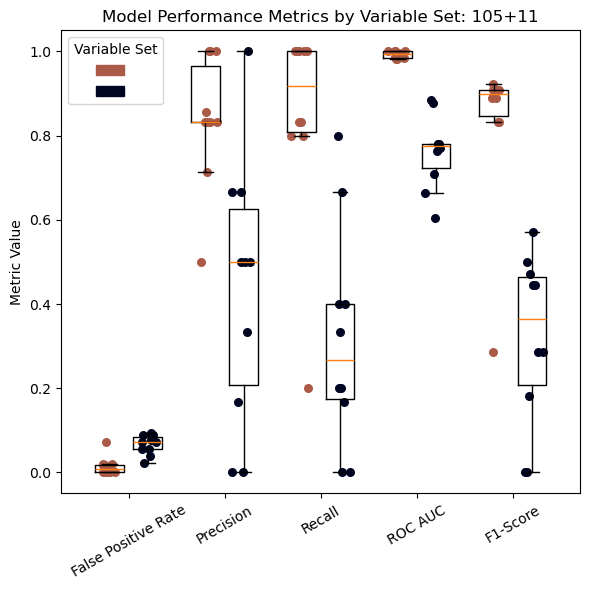

In [207]:
import matplotlib.patches as mpatches
# Unpack metrics
names = ['False Positive Rate', 'Precision', 'Recall', 'ROC AUC', 'F1-Score']

metrics_list = [biometrics, clinmetrics]
# Plotting results with black and cyan dots
plt.figure(figsize=[6, 6])

# Define colors for each variable set
colors = ['#AB5A47', '#000521']

for i, metricss in enumerate(metrics_list):
    positions = np.arange(len(names)) + i * 0.4 -0.2 # Shift positions for side-by-side boxplots
    
    for l, metrica in enumerate(metricss):
        plt.boxplot(metrica, positions=[positions[l]], widths=0.3, showfliers=False)
        jitters = np.random.normal(0, 0.05, len(metrica))  # Add jitter for scatter points
        
        # Scatter points with specified colors
        for j in range(len(metrica)):
            plt.scatter(positions[l] + jitters[j], metrica[j], color=colors[i], s=30)

# Custom ticks and legends
plt.xticks(ticks=np.arange(len(names)), labels=names, rotation=30)
legend_handles = [
    mpatches.Patch(color='#AB5A47'),
    mpatches.Patch(color='#000521')
]
plt.legend(handles=legend_handles, title='Variable Set')
plt.title('Model Performance Metrics by Variable Set: 105+11')
plt.ylabel('Metric Value')
plt.tight_layout()

# Save the plot
plt.savefig('graphs/fig4_comparison_boxplots.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()

In [208]:
metricsbio_df = pd.DataFrame(biometrics, index = names).T
metricsclin_df = pd.DataFrame(clinmetrics, index = names).T
metricsbio_df['source'] = 'metricsbio'
metricsclin_df['source'] = 'metricsclin'
metrics_df = pd.concat([metricsbio_df, metricsclin_df], ignore_index=True)
metrics_df.to_csv('extendeddata/f4a_data.csv', index=False)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


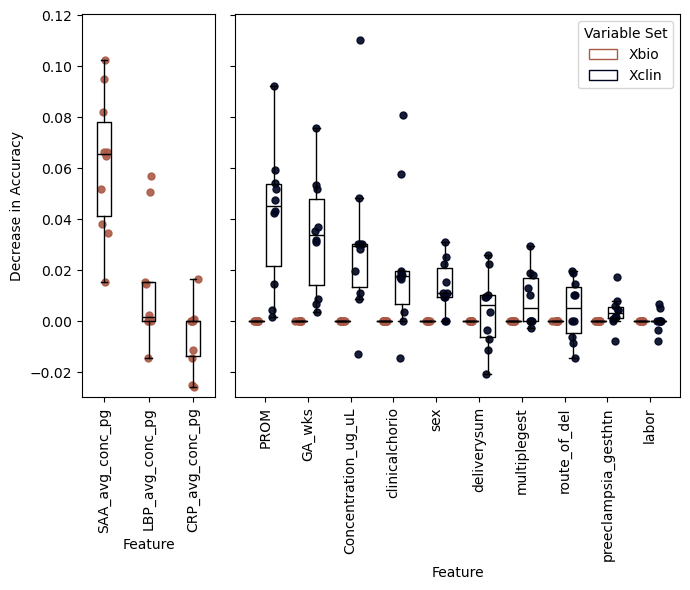

In [243]:
# Ensure biofeat and clinfeat are DataFrames
biofeat = pd.DataFrame(bioperm).T
clinfeat = pd.DataFrame(clinperm).T

# Identify shared and unique features
shared_features = biofeat.index.intersection(clinfeat.index)
bio_only_features = biofeat.index.difference(clinfeat.index)

# Sort features by median importance
bio_sorted = biofeat.loc[bio_only_features].mean(axis=1).sort_values(ascending=False).index
shared_sorted = clinfeat.loc[shared_features].median(axis=1).sort_values(ascending=False).index

# Set up figure
fig, (ax1, ax2) = plt.subplots(1, 2,
    figsize=(max(6, len(shared_sorted) * 0.7), 6),
    gridspec_kw={'width_ratios': [3, 10]},
    sharey=True
)
# --- Panel 1: Bio-only features (vertical) ---
bio_data = biofeat.loc[bio_sorted]

biofeat.loc[bio_sorted].T.boxplot(
    vert=True, ax=ax1, color='black', showfliers=False, patch_artist=False
)
for i, feat in enumerate(bio_sorted):
    values = bio_data.loc[feat]
    x_pos = np.random.normal(i + 1, 0.05, size=len(values))  # i+1 because boxplot positions start at 1
    ax1.scatter(x_pos, values, color='#AB5A47', s=25, alpha=0.9)
#ax1.set_title("Bio-only Features: Permutation Importance")
ax1.set_ylabel("Decrease in Accuracy")
ax1.set_xlabel("Feature")
ax1.tick_params(axis='x', rotation=90)
ax1.grid(False)

# --- Panel 2: Shared features (open boxplots, side-by-side) ---
data = []
positions = []
labels = []
width = 0.35
offset = 0.2

xticks = []
xticklabels = []

for i, feat in enumerate(shared_sorted):
    # Xbio
    data.append(biofeat.loc[feat])
    positions.append(i - offset)
    
    # Xclin
    data.append(clinfeat.loc[feat])
    positions.append(i + offset)

    xticks.append(i)
    xticklabels.append(feat)

# Plot open boxplots for both models
box = ax2.boxplot(data, vert=True, positions=positions, widths=width,
                  patch_artist=False, showfliers=False)
for median in box['medians']:
    median.set_color('black')
# Set x-ticks centered between the paired boxes
ax2.set_xticks(xticks)
ax2.set_xticklabels(xticklabels, rotation=90)
#ax2.set_title("Shared Features: Permutation Importance")
#ax2.set_ylabel("Decrease in Accuracy")
ax2.set_xlabel("Feature")
ax2.grid(False)

# Overlay scatter points with color to distinguish variable sets
colors = ['#AB5A47', '#000521']
for i, series in enumerate(data):
    x_pos = positions[i] + np.random.normal(0, 0.03, size=len(series))
    ax2.scatter(x_pos, series, color=colors[i % 2], s=25, alpha=0.9)
# Add legend
legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor=colors[0], label='Xbio'),
    mpatches.Patch(facecolor='none', edgecolor=colors[1], label='Xclin')
]
ax2.legend(handles=legend_handles, title='Variable Set', loc='upper right')
# Determine global Y-axis limits
all_data = pd.concat([biofeat.loc[bio_only_features], biofeat.loc[shared_features], clinfeat.loc[shared_features]])
ymin = all_data.min().min()
ymax = all_data.max().max()

# Set consistent y-axis limits
ax1.set_ylim(ymin-0.004, ymax+0.01)
ax2.set_ylim(ymin-0.004, ymax+0.01)
plt.tight_layout()
plt.savefig('graphs/fig4_ML_perm_importance_split_panels_vertical_INTERNALFOLDS.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()


In [247]:
# save f4b data
bioperm['source'] = 'biofeat'
clinperm['source'] = 'clinfeat'
importance_df = pd.concat([bioperm, clinperm], ignore_index=True)
importance_df.to_csv('extendeddata/f4b_data.csv', index=False)

In [231]:
# Look at permutation importances of the final model.
# For biomarker-based model
perm_final_bio = permutation_importance(
    final_rf_bio, Xbio, Y,
    n_repeats=20, random_state=42, n_jobs=-1
)
final_bio_importances = pd.DataFrame(perm_final_bio.importances.T, columns=Xbio.columns)

# For clinical model
perm_final_clin = permutation_importance(
    final_rf_clin, Xclin, Y,
    n_repeats=20, random_state=42, n_jobs=-1
)
final_clin_importances = pd.DataFrame(perm_final_clin.importances.T, columns=Xclin.columns)


import seaborn as sns
import matplotlib.pyplot as plt

# Sort features by mean importance
bio_sorted = final_clin_importances.mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_clin_importances[bio_sorted], showfliers=False, color='lightblue')
sns.stripplot(data=final_clin_importances[bio_sorted], color='black', size=3, jitter=True)

plt.xticks(rotation=90)
plt.ylabel("Permutation importance")
plt.title("Final model permutation importances (bio)")
plt.tight_layout()
plt.show()
# They are basically the same as the between the folds

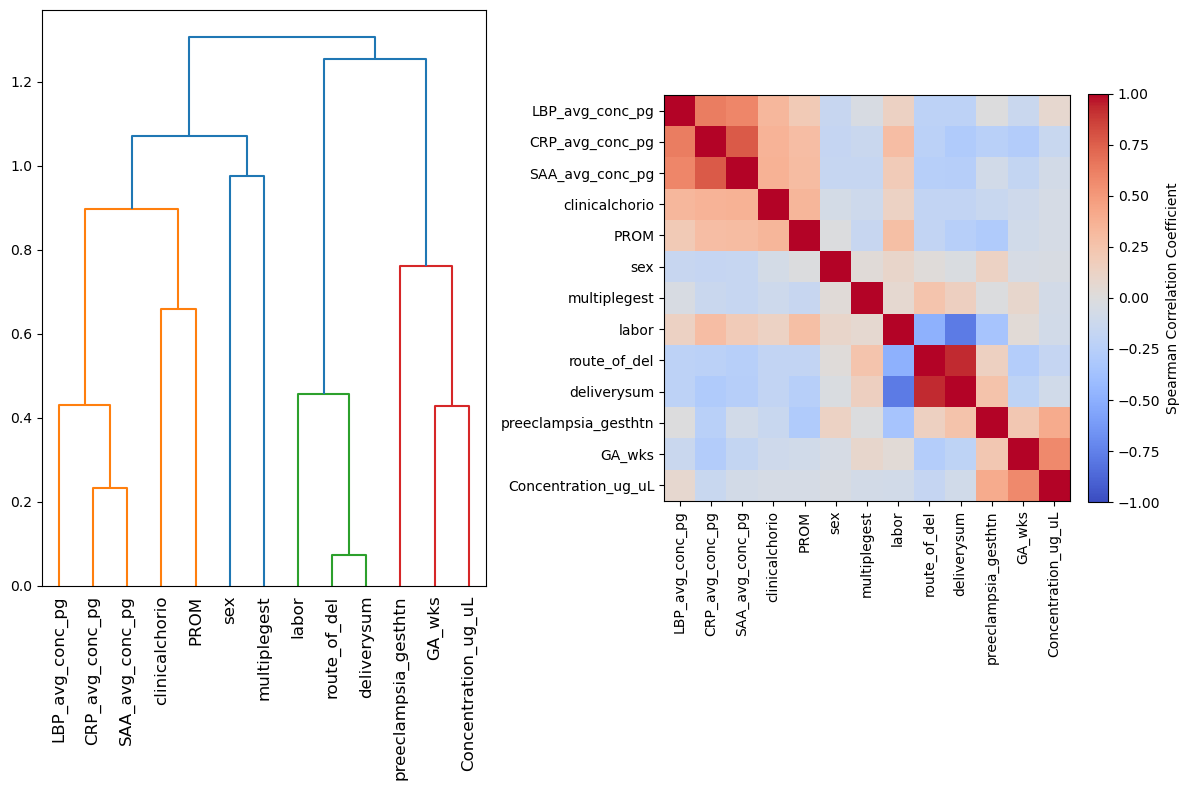

In [248]:
# supplemental figure 2

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = spearmanr(X).correlation

corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))

ordered_corr = corr[dendro["leaves"], :][:, dendro["leaves"]]
im = ax2.imshow(
    ordered_corr, cmap='coolwarm', vmin=-1, vmax=1  
)
cbar = fig.colorbar(im, ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Spearman Correlation Coefficient')

#ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
_ = fig.tight_layout()


plt.savefig('graphs/s2_collinearity_WBIO.eps', format='eps', bbox_inches='tight')
plt.show()

In [249]:
corr_df = pd.DataFrame(corr, index=X.columns, columns=X.columns)
corr_df.to_csv('extendeddata/s4_data.csv', index=True)

In [ ]:
### Figure 5

In [269]:
#using the model to classify presumed sepsis patients into EOS or Control
ps_notlab['majority_label']= final_rf_bio.predict(ps_notlab.loc[:,['CRP_avg_conc_pg','SAA_avg_conc_pg', 'LBP_avg_conc_pg', 'GA_wks', 'sex', 'multiplegest', 'preeclampsia_gesthtn', 'route_of_del', 'labor', 'deliverysum', 'clinicalchorio', 'PROM', 'Concentration_ug_uL']])
ctrl = ps_notlab[ps_notlab['majority_label']=='Control']
mesoscale['reclassify'] = final_rf_bio.predict(mesoscale.loc[:,['CRP_avg_conc_pg','SAA_avg_conc_pg', 'LBP_avg_conc_pg', 'GA_wks', 'sex', 'multiplegest', 'preeclampsia_gesthtn', 'route_of_del', 'labor', 'deliverysum', 'clinicalchorio', 'PROM', 'Concentration_ug_uL']])
# DO NOT read too much into how final_rf_bio has reclassified the samples it has already seen (ie, premature controls and non-outlier EOS)

In [272]:
#pd.Series(ps_notlab[ps_notlab['sample_type_y'] == 'PS']['majority_label']).value_counts()
pd.Series(mesoscale[mesoscale['sample_type_y'] == 'PS']['reclassify']).value_counts()

reclassify
Control    41
EOS        12
Name: count, dtype: int64

3.5808725864347294e-07
1.8135151397828814e-07
5.586864409316926e-07


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


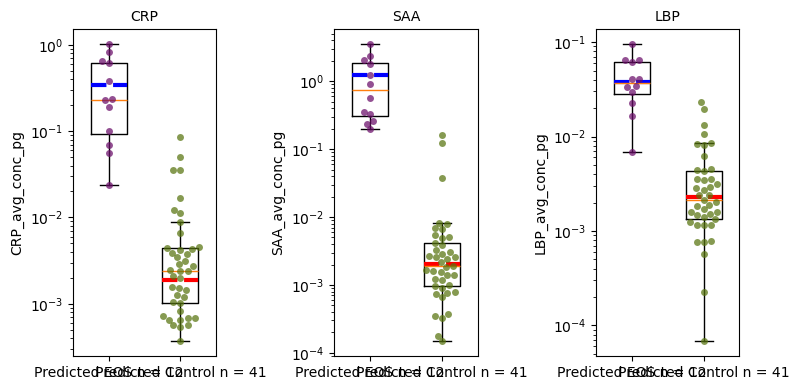

In [260]:
# Boxplot of the 3 proteins for presumed sepsis patients split by the predicted label


ctrl_medians = {}
eos_medians = {}
PG_TO_MG = 1e-9

for p in range(len(genes)):
    prot = genes[p]
    count += 1
    eos = (mesoscale_cut[mesoscale_cut['sample_type_x']=='EOS'][prot].dropna()) * PG_TO_MG
    ctrl = (mesoscale_cut[mesoscale_cut['sample_type_x']=='Control'][prot].dropna()) * PG_TO_MG
    ctrl_medians[prot] = ctrl.median()
    eos_medians[prot] = eos.median()
# use mesoscale_cut here bc it doesn't make sense to calculate median EOS concentrations 
# with the 3 that we think had something that might reasonably be called "late onset" EOS


sns.set(font_scale=0.3)
plt.style.use('default')

plt.figure(figsize=[8, 4])
colnames = [
    'CRP_avg_conc_pg',
    'SAA_avg_conc_pg',
    'LBP_avg_conc_pg'
]

PG_TO_MG = 1e-9  # Conversion factor from pg to mg
count = 0

for c in range(len(colnames)):
    col = colnames[c]
    count += 1
    ax = plt.subplot(1, 3, count)

    # Apply conversion to mg
    ctrl = ps_notlab[ps_notlab['majority_label'] == 'Control'][col].dropna() * PG_TO_MG
    eos = ps_notlab[ps_notlab['majority_label'] == 'EOS'][col].dropna() * PG_TO_MG
    #pctrl = ps_notlab[ps_notlab['majority_label'] == 'Control']['prob']
    #peos = ps_notlab[ps_notlab['majority_label'] == 'EOS']['prob']
    # Boxplots
    box_ctrl = ax.boxplot(ctrl, positions=[1],
                          labels=[f'Predicted Control n = {ctrl.shape[0]}'],
                          widths=0.5, showfliers=False)
    second_median_ctrl = ctrl_medians[col] # Converted median for Control

    for median in box_ctrl['medians']:
        median_coords = median.get_xydata()
        x0, x1 = median_coords[:, 0]
        ax.plot([x0, x1], [second_median_ctrl, second_median_ctrl],
                color='red', linestyle='--', linewidth=3)

    sns.swarmplot(y=eos, color='#6a0d69', alpha=0.72)
    sns.swarmplot(y=ctrl, x=1, color='#57740e', alpha=0.72)
    #cmap = mpl.get_cmap('coolwarm')
    #sns.swarmplot(y=eos, color=cmap(peos), alpha=0.72)
    #sns.swarmplot(y=ctrl, x=1, color=cmap(pctrl), alpha=0.72)

    box_eos = ax.boxplot(eos, positions=[0],
                         labels=[f'Predicted EOS n = {eos.shape[0]}'],
                         widths=0.5, showfliers=False)
    second_median_eos = eos_medians[col]   # Converted median for EOS

    for median in box_eos['medians']:
        median_coords = median.get_xydata()
        x0, x1 = median_coords[:, 0]
        ax.plot([x0, x1], [second_median_eos, second_median_eos],
                color='blue', linestyle='--', linewidth=3)

    # Set y-axis to log scale
    plt.yscale('log')

    # Mann-Whitney U test
    pval = stats.mannwhitneyu(ctrl, eos).pvalue
    ax.set_title(f'{col.split("_")[0]}', fontsize=10)
    print(pval)

plt.tight_layout()
plt.savefig('graphs/fig5_ps_boxplots_logged.eps', format = 'eps', bbox_inches = 'tight')

plt.show()
plt.close()



In [273]:
f5b_data = ps_notlab[['sample_type_y', 'sample_id', 'majority_label'] + colnames]
#f2c_data = new_df[['sample_type', 'sample_id'] + genes]

f5b_data.to_csv('extendeddata/f5b_data.csv', index=True)

In [276]:
newlabs = []
for sid in mesoscale.index:
    newlabs.append(mesoscale.loc[sid, 'sample_type_x'] + mesoscale.loc[sid,'reclassify'])
pd.Series(newlabs).value_counts()
# again, do not read too much into categories not beginning with PS.

In [301]:
tmpdf

,CRP_avg_conc_pg_log,SAA_avg_conc_pg_log,LBP_avg_conc_pg_log
sample_id,,,
NU163,12.322027,13.678561,13.950961
BP016,12.414242,13.363362,14.776954
P041,12.444853,12.916754,14.134364
BP1160,12.534556,14.317403,13.782955
BP929,12.744922,11.924253,13.606060
...,...,...,...
P222,19.749651,21.440595,17.514138
BP794,20.228626,19.601554,17.993523
BP778,20.303078,19.692610,17.349581


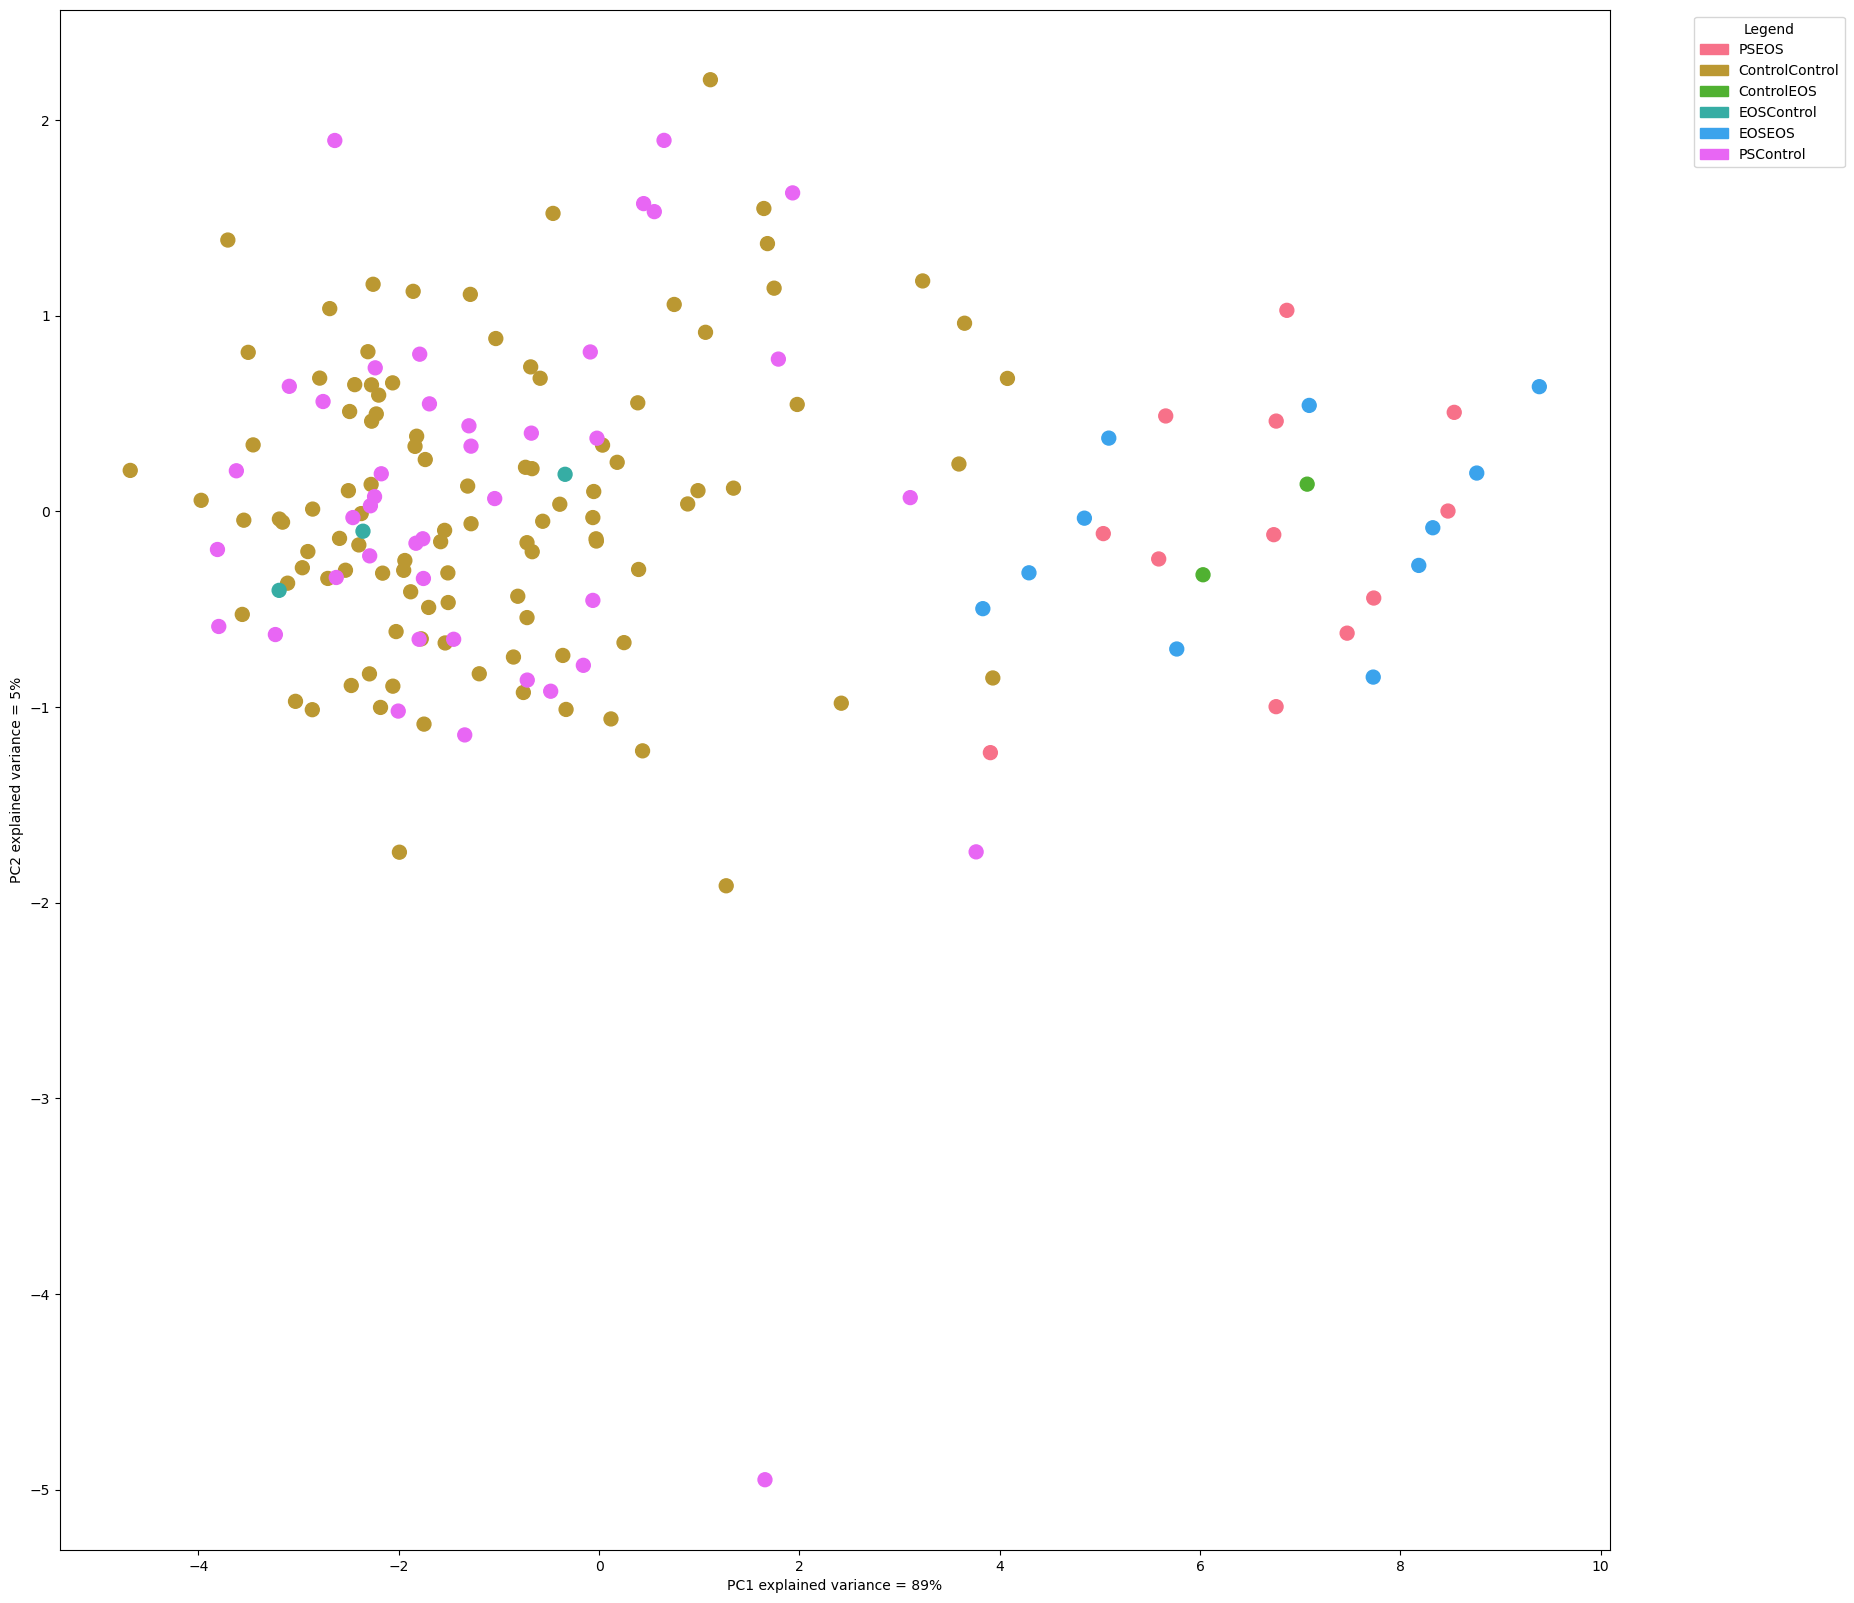

In [302]:
#replotting PCA with presumed sepsis patients and colored by their predicted label
from sklearn.decomposition import PCA

unique_labels = list(set(newlabs))
palette = sns.color_palette("husl", len(unique_labels))  # 'husl' provides distinguishable colors
color_dict = dict(zip(unique_labels, palette))  # Map unique labels to colors

# Map colors to each point
row_colors = pd.Series(newlabs).map(color_dict)
sns.set(font_scale=2)

plt.style.use('default')

plt.figure(figsize = [20,20])
pca = PCA(n_components=2)
x_new = pca.fit_transform(tmpdf)
x_new_df = pd.DataFrame(x_new)
x_new_df.index = tmpdf.index

plt.scatter(x_new_df.iloc[:,0], x_new_df.iloc[:,1], color = row_colors, s = 100)
plt.xlabel('PC1 explained variance = {}%'.format(int(pca.explained_variance_ratio_[0]*100)))
plt.ylabel('PC2 explained variance = {}%'.format(int(pca.explained_variance_ratio_[1]*100)))
legend_handles = [mpatches.Patch(color=color_dict[label], label=label) for label in unique_labels]
plt.legend(handles=legend_handles, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

#plt.savefig('graphs/reclassify_knowns.png', dpi=300, bbox_inches="tight")
#plt.savefig('graphs/fig5a_reclassify.eps', format = 'eps', bbox_inches = 'tight')

plt.show()
#for i, txt in enumerate(x_new_df.index):
#    plt.annotate(txt, (x_new_df.iloc[i,0], x_new_df.iloc[i,1]), fontsize = 10)



In [309]:
x_new_df

,0,1
sample_id,,
NU163,-3.562506,-0.526841
BP016,-3.454129,0.339572
P041,-3.972944,0.056271
BP1160,-3.031036,-0.971123
BP929,-4.681199,0.209139
...,...,...
P222,7.734739,-0.443161
BP794,6.867351,1.027296
BP778,6.760871,0.461272


In [311]:
f5a_data = pd.DataFrame(
    data=x_new,
    columns=['PC1', 'PC2']  
)

f5a_data['sample_id'] = tmpdf.index
f5a_data['newlabs'] = newlabs

f5a_data.to_csv('extendeddata/f5a_data.csv', index=False)


In [312]:
import pandas as pd
import os
from pathlib import Path

# Directory where your CSVs are stored
csv_dir = Path('extendeddata')
output_excel = 'extendeddata_compiled.xlsx'

# Get all .csv files
csv_files = list(csv_dir.glob('*.csv'))

# Write to Excel
with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    for csv_file in csv_files:
        sheet_name = csv_file.stem[:31]  # Sheet names must be <= 31 characters
        df = pd.read_csv(csv_file)
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Excel file saved as: {output_excel}")


Excel file saved as: ExtendedData_Compiled.xlsx
